# 0. Libraries

!! Run this in the terminal: pip install -r requirements.txt

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# 1. Dataset Preparation & Analysis

## 1.1.Loading datasets & cleaning

### 1.1.1. Dataset loading

Instagram

In [2]:
ig1 = pd.read_csv("data/dataset_instagram-hashtag-scraper_2026-03-04_11-38-57-137.csv")
ig2 = pd.read_csv("data/instagram_hashtags.csv")

with open("data/instagram_posts.json") as f:
    ig3 = pd.DataFrame(json.load(f))

core_cols = ['caption', 'ownerFullName', 'ownerUsername', 'url', 
             'commentsCount', 'likesCount', 'timestamp']

ig1_clean = ig1[core_cols].copy()
ig2_clean = ig2[core_cols].copy()
ig3_clean = ig3[core_cols].copy()

ig1_clean['source'] = 'hashtag_1'
ig2_clean['source'] = 'hashtag_2'
ig3_clean['source'] = 'profile'

instagram_all = pd.concat([ig1_clean, ig2_clean, ig3_clean], ignore_index=True)

instagram_all['timestamp'] = pd.to_datetime(instagram_all['timestamp'], utc=True)
instagram_all.drop_duplicates(subset=['url'], inplace=True)
instagram_all.reset_index(drop=True, inplace=True)

bag_keywords = {
    "Chanel Classic Flap":      ["chanel classic", "classic flap", "chanel flap",
                                  "chanelclassicflap", "chanelclassic", "coco chanel",
                                  "diana", "caviar chanel", "chanel"],
    "Hermes Birkin":            ["birkin", "hermès birkin", "hermes birkin"],
    "Hermes Kelly":             ["kelly", "hermès kelly", "hermes kelly"],
    "Dior Saddle Bag":          ["dior saddle", "saddle bag", "diorsaddle"],
    "Bottega Veneta Pouch":     ["bottega", "bv pouch", "intrecciato"],
    "Louis Vuitton Capucines":  ["capucines", "lv capucines", "louisvuittoncapucines"],
}

def assign_bag(text):
    if not isinstance(text, str):
        return "Unknown"
    t = text.lower()
    for bag, kws in bag_keywords.items():
        if any(k in t for k in kws):
            return bag
    return "Unknown"

instagram_all['bag_query'] = instagram_all['caption'].apply(assign_bag)

instagram_clean_final = instagram_all[instagram_all['bag_query'] != 'Unknown'].copy()
instagram_clean_final['month'] = instagram_clean_final['timestamp'].dt.to_period('M').dt.to_timestamp()

instagram_clean_final.to_csv("data/instagram_merged.csv", index=False)

print(f"Total rows: {len(instagram_all)}")
print(f"Duplicates removed: {(369+342+1836) - len(instagram_all)}")
print(f"\nBag distribution:")
print(instagram_all['bag_query'].value_counts())
print(f"\nDate range: {instagram_all['timestamp'].min()} → {instagram_all['timestamp'].max()}")
print(f"\nUnknown posts: {(instagram_all['bag_query'] == 'Unknown').sum()}")

Total rows: 2503
Duplicates removed: 44

Bag distribution:
bag_query
Unknown                    1493
Chanel Classic Flap         440
Bottega Veneta Pouch        204
Hermes Birkin               138
Louis Vuitton Capucines     105
Hermes Kelly                 67
Dior Saddle Bag              56
Name: count, dtype: int64

Date range: 2020-04-25 17:20:42+00:00 → 2026-03-04 11:25:00+00:00

Unknown posts: 1493


Datasets

In [3]:
ebay    = pd.read_csv("data/ebay.csv")
youtube = pd.read_csv("data/youtube.csv")
tiktok  = pd.read_csv("data/tiktok.csv")
google  = pd.read_csv("data/google.csv")
instagram = pd.read_csv("data/instagram_merged.csv")

Dataset Overview

In [4]:
for name, df in [("eBay", ebay), ("YouTube", youtube), ("TikTok", tiktok), 
                  ("Google", google), ("Instagram", instagram)]:
    print(f"\n{'='*40}")
    print(f"{name} — shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Nulls:\n{df.isnull().sum()}")
    print(df.head(2))


eBay — shape: (2044, 6)
Columns: ['bag_query', 'title', 'sold_price', 'sold_date', 'listing_url', 'scraped_at']
Nulls:
bag_query      0
title          0
sold_price     0
sold_date      0
listing_url    0
scraped_at     0
dtype: int64
              bag_query                                              title  \
0  Bottega Veneta Pouch  BOTTEGA VENETA Shoulder Bag Intrecciato Leathe...   
1  Bottega Veneta Pouch  BOTTEGA VENETA Pouch Makeup Case Leather Borde...   

   sold_price     sold_date  \
0     1539.00   Sep 3, 2024   
1      272.81  Nov 30, 2025   

                                         listing_url  scraped_at  
0  https://www.ebay.com/itm/315290103553?_skw=Bot...  2026-02-23  
1  https://www.ebay.com/itm/397284574836?_skw=Bot...  2026-02-23  

YouTube — shape: (1216, 10)
Columns: ['video_id', 'title', 'channel', 'published_at', 'view_count', 'like_count', 'comment_count', 'url', 'bag_query', 'scraped_at']
Nulls:
video_id         0
title            0
channel          1
publi

Color Palette

In [5]:
sns.set_theme(style="whitegrid")
COLORS = ["#2E4057", "#E84855", "#F4A261", "#2A9D8F", "#A8DADC", "#6A0572"]
BAG_COLORS = dict(zip([
    "Chanel Classic Flap", "Hermes Birkin", "Hermes Kelly",
    "Dior Saddle Bag", "Bottega Veneta Pouch", "Louis Vuitton Capucines"
], COLORS))

Date Parsing

In [6]:
ebay['sold_date'] = pd.to_datetime(ebay['sold_date'], errors='coerce')

youtube['published_at'] = pd.to_datetime(youtube['published_at'], utc=True, errors='coerce')
if youtube['published_at'].isna().all():
    youtube['published_at'] = pd.to_datetime(youtube['published_at'], unit='s', utc=True, errors='coerce')
youtube['published_at'] = youtube['published_at'].dt.tz_localize(None)

tiktok['createTimeISO']  = pd.to_datetime(tiktok['createTimeISO'],  utc=True, errors='coerce').dt.tz_localize(None)
instagram['timestamp']   = pd.to_datetime(instagram['timestamp'],   utc=True, errors='coerce').dt.tz_localize(None)
google['month']          = pd.to_datetime(google['month'])

ebay['month']      = ebay['sold_date'].dt.to_period('M').dt.to_timestamp()
youtube['month']   = youtube['published_at'].dt.to_period('M').dt.to_timestamp()
tiktok['month']    = tiktok['createTimeISO'].dt.to_period('M').dt.to_timestamp()
instagram['month'] = instagram['timestamp'].dt.to_period('M').dt.to_timestamp()

for name, df, col in [("YouTube", youtube, 'published_at'), ("TikTok", tiktok, 'createTimeISO'),
                       ("Instagram", instagram, 'timestamp')]:
    print(f"{name}: {df[col].min()} → {df[col].max()}")

YouTube: 2023-01-02 14:23:29 → 2026-03-04 08:32:12
TikTok: 2020-07-15 17:44:10 → 2026-03-03 23:54:57
Instagram: 2020-04-25 17:20:42 → 2026-03-04 11:25:00


### 1.1.2. Keyword matching

In [7]:
bag_keywords = {
    "Chanel Classic Flap":      ["chanel classic", "classic flap", "chanel flap",
                                  "chanelclassicflap", "chanelclassic", "coco chanel",
                                  "diana", "caviar chanel", "chanel"],
    "Hermes Birkin":            ["birkin", "hermès birkin", "hermes birkin"],
    "Hermes Kelly":             ["kelly", "hermès kelly", "hermes kelly"],
    "Dior Saddle Bag":          ["dior saddle", "saddle bag", "diorsaddle"],
    "Bottega Veneta Pouch":     ["bottega", "bv pouch", "intrecciato"],
    "Louis Vuitton Capucines":  ["capucines", "lv capucines", "louisvuittoncapucines"],
}

def assign_bag(text):
    if not isinstance(text, str):
        return "Unknown"
    t = text.lower()
    for bag, kws in bag_keywords.items():
        if any(k in t for k in kws):
            return bag
    return "Unknown"

tiktok['bag_query']    = tiktok['text'].apply(assign_bag)
instagram['bag_query'] = instagram['caption'].apply(assign_bag)

Filter Unknowns & Reshape Google

In [8]:
tiktok    = tiktok[tiktok['bag_query'] != "Unknown"].copy()
instagram = instagram[instagram['bag_query'] != "Unknown"].copy()
google = google.melt(id_vars='month', var_name='bag_query', value_name='search_index')


### 1.1.3. Price Floors & Retail Prices

In [9]:
retail_prices = {
    "Chanel Classic Flap":      10800,
    "Hermes Birkin":            15000,
    "Hermes Kelly":             12000,
    "Dior Saddle Bag":          3900,
    "Bottega Veneta Pouch":     4200,
    "Louis Vuitton Capucines":  6350,
}

bag_price_floors = {
    "Chanel Classic Flap":      2000,
    "Hermes Birkin":            5000,
    "Hermes Kelly":             4000,
    "Dior Saddle Bag":          800,
    "Bottega Veneta Pouch":     1500,
    "Louis Vuitton Capucines":  1500,
}

ebay_raw = ebay.copy()

ebay['price_floor'] = ebay['bag_query'].map(bag_price_floors)
ebay = ebay[ebay['sold_price'] >= ebay['price_floor']].copy()

print("\nEBAY RESALE PRICE STATISTICS\n")
ebay_stats = (
    ebay
    .groupby('bag_query')['sold_price']
    .agg(
        N       = 'count',
        Mean    = 'mean',
        Median  = 'median',
        Std     = 'std',
        Min     = 'min',
        Max     = 'max',
    )
    .round(0)
    .reset_index()
)
ebay_stats['Retail Price']   = ebay_stats['bag_query'].map(retail_prices)
ebay_stats['Price Floor']    = ebay_stats['bag_query'].map(bag_price_floors)
ebay_stats['Resale Premium'] = ((ebay_stats['Mean'] - ebay_stats['Retail Price']) / ebay_stats['Retail Price']).round(3)
print(ebay_stats.to_string(index=False))


EBAY RESALE PRICE STATISTICS

              bag_query   N    Mean  Median    Std    Min     Max  Retail Price  Price Floor  Resale Premium
   Bottega Veneta Pouch  18  1900.0  1615.0  462.0 1500.0  3000.0          4200         1500          -0.548
    Chanel Classic Flap 348  4004.0  3500.0 1738.0 2000.0 10200.0         10800         2000          -0.629
        Dior Saddle Bag 273  1944.0  1700.0 1153.0  800.0  8100.0          3900          800          -0.502
          Hermes Birkin 232 12721.0 11377.0 5315.0 5000.0 41200.0         15000         5000          -0.152
           Hermes Kelly 282  9403.0  8399.0 4272.0 4059.0 33373.0         12000         4000          -0.216
Louis Vuitton Capucines 118  3313.0  2541.0 1713.0 1500.0  7645.0          6350         1500          -0.478


### 1.1.4. Weekly Aggreagtion Pipeline

In [10]:
from functools import reduce

WEEKLY_START = pd.Timestamp("2023-01-01")

def to_week(df, date_col):
    df = df.copy()
    df['week'] = pd.to_datetime(df[date_col]).dt.to_period('W').dt.to_timestamp()
    return df

ebay_w      = to_week(ebay,      'sold_date')
youtube_w   = to_week(youtube,   'published_at')
tiktok_w    = to_week(tiktok,    'createTimeISO')
instagram_w = to_week(instagram_clean_final, 'timestamp')
google_w    = to_week(google,    'month')

ebay_weekly = (
    ebay_w
    .assign(price_floor=lambda x: x['bag_query'].map(bag_price_floors))
    .pipe(lambda x: x[x['sold_price'] >= x['price_floor']])
    .query("week >= @WEEKLY_START")
    .groupby(['week', 'bag_query'])
    .agg(
        avg_resale_price    = ('sold_price', 'mean'),
        median_resale_price = ('sold_price', 'median'),
        sales_volume        = ('sold_price', 'count'),
    )
    .reset_index()
)

youtube_weekly = (
    youtube_w
    .query("week >= @WEEKLY_START")
    .groupby(['week', 'bag_query'])
    .agg(
        yt_total_views = ('view_count', 'sum'),
        yt_total_likes = ('like_count', 'sum'),
        yt_video_count = ('video_id',   'count'),
    )
    .reset_index()
)

tiktok_weekly = (
    tiktok_w
    .query("week >= @WEEKLY_START")
    .groupby(['week', 'bag_query'])
    .agg(
        tt_total_plays = ('playCount', 'sum'),
        tt_total_likes = ('diggCount', 'sum'),
        tt_video_count = ('playCount', 'count'),
    )
    .reset_index()
)

instagram_weekly = (
    instagram_w
    .query("week >= @WEEKLY_START")
    .groupby(['week', 'bag_query'])
    .agg(
        ig_total_likes    = ('likesCount',    'sum'),
        ig_total_comments = ('commentsCount', 'sum'),
        ig_post_count     = ('likesCount',    'count'),
        ig_avg_likes      = ('likesCount',    'mean'),
    )
    .reset_index()
)

google_weekly = (
    google_w
    .query("week >= @WEEKLY_START")
    .groupby(['week', 'bag_query'])
    .agg(search_index = ('search_index', 'mean'))
    .reset_index()
)

dfs_weekly = [ebay_weekly, google_weekly, youtube_weekly, tiktok_weekly, instagram_weekly]
df_weekly = reduce(
    lambda left, right: pd.merge(left, right, on=['week', 'bag_query'], how='outer'),
    dfs_weekly
)
df_weekly = df_weekly.sort_values(['bag_query', 'week']).reset_index(drop=True)

df_weekly['retail_price']   = df_weekly['bag_query'].map(retail_prices)
df_weekly['resale_premium'] = (
    (df_weekly['avg_resale_price'] - df_weekly['retail_price']) / df_weekly['retail_price']
)

for col in ['search_index', 'tt_total_plays', 'yt_total_views', 'ig_total_likes']:
    df_weekly[f'{col}_lag1'] = df_weekly.groupby('bag_query')[col].shift(1)

fill_cols = ['search_index', 'yt_total_views', 'tt_total_plays', 'ig_total_likes',
             'search_index_lag1', 'tt_total_plays_lag1',
             'yt_total_views_lag1', 'ig_total_likes_lag1']

df_weekly[fill_cols] = df_weekly.groupby('bag_query')[fill_cols].transform(lambda x: x.ffill())
for col in fill_cols:
    df_weekly[col] = df_weekly[col].fillna(df_weekly[col].median())

df_weekly.to_csv("data/features_weekly.csv", index=False)

df_model_weekly = df_weekly.dropna(subset=['avg_resale_price']).copy()

print(f"Total weekly rows: {len(df_weekly)}")
print(f"Rows with price data: {len(df_model_weekly)}")
print(f"Date range: {df_weekly['week'].min()} → {df_weekly['week'].max()}")
print(f"\nPrice rows per bag:")
print(df_model_weekly['bag_query'].value_counts())

Total weekly rows: 858
Rows with price data: 80
Date range: 2023-01-02 00:00:00 → 2026-03-02 00:00:00

Price rows per bag:
bag_query
Dior Saddle Bag            15
Chanel Classic Flap        14
Hermes Birkin              14
Hermes Kelly               14
Louis Vuitton Capucines    13
Bottega Veneta Pouch       10
Name: count, dtype: int64


## 1.2. Descriptive Statistics

### 1.2.1. Full Dataset

In [11]:
print("\n DATASET OVERVIEW \n")
overview = pd.DataFrame([
    {
        "Dataset":    "eBay Sold Listings",
        "Rows":       len(ebay),
        "Date From":  ebay['sold_date'].min().strftime('%Y-%m-%d'),
        "Date To":    ebay['sold_date'].max().strftime('%Y-%m-%d'),
        "Bags":       ebay['bag_query'].nunique(),
        "Key Variable": "sold_price"
    },
    {
        "Dataset":    "Google Trends",
        "Rows":       len(google),
        "Date From":  google['month'].min().strftime('%Y-%m-%d'),
        "Date To":    google['month'].max().strftime('%Y-%m-%d'),
        "Bags":       google['bag_query'].nunique(),
        "Key Variable": "search_index"
    },
    {
        "Dataset":    "YouTube",
        "Rows":       len(youtube),
        "Date From":  youtube['published_at'].min().strftime('%Y-%m-%d'),
        "Date To":    youtube['published_at'].max().strftime('%Y-%m-%d'),
        "Bags":       youtube['bag_query'].nunique(),
        "Key Variable": "view_count"
    },
    {
        "Dataset":    "TikTok",
        "Rows":       len(tiktok),
        "Date From":  tiktok['createTimeISO'].min().strftime('%Y-%m-%d'),
        "Date To":    tiktok['createTimeISO'].max().strftime('%Y-%m-%d'),
        "Bags":       tiktok['bag_query'].nunique(),
        "Key Variable": "playCount"
    },
    {
        "Dataset":    "Instagram",
        "Rows":       len(instagram_clean_final),
        "Date From":  instagram_clean_final['timestamp'].min().strftime('%Y-%m-%d'),
        "Date To":    instagram_clean_final['timestamp'].max().strftime('%Y-%m-%d'),
        "Bags":       instagram_clean_final['bag_query'].nunique(),
        "Key Variable": "likesCount"
    },
])
print(overview.to_string(index=False))


 DATASET OVERVIEW 

           Dataset  Rows  Date From    Date To  Bags Key Variable
eBay Sold Listings  1271 2024-09-03 2026-02-23     6   sold_price
     Google Trends   588 2018-01-01 2026-02-01     6 search_index
           YouTube  1216 2023-01-02 2026-03-04     7   view_count
            TikTok  1135 2021-01-24 2026-03-03     6    playCount
         Instagram  1010 2020-04-25 2026-03-04     6   likesCount


### 1.2.2. Google Trends

In [12]:
print("\n GOOGLE TRENDS SEARCH INDEX STATISTICS \n")
google_stats = (
    google
    .groupby('bag_query')['search_index']
    .agg(
        N      = 'count',
        Mean   = 'mean',
        Std    = 'std',
        Min    = 'min',
        Max    = 'max',
    )
    .round(3)
    .reset_index()
)
print(google_stats.to_string(index=False))


 GOOGLE TRENDS SEARCH INDEX STATISTICS 

              bag_query  N  Mean   Std   Min   Max
   Bottega Veneta Pouch 98 0.074 0.034 0.000 0.150
    Chanel Classic Flap 98 0.329 0.113 0.147 0.735
        Dior Saddle Bag 98 0.658 0.214 0.029 1.000
          Hermes Birkin 98 1.520 0.526 0.765 2.941
           Hermes Kelly 98 1.255 0.532 0.559 2.529
Louis Vuitton Capucines 98 0.071 0.030 0.030 0.160


### 1.2.3. Social Media Engagement

In [13]:
youtube['view_count']    = pd.to_numeric(youtube['view_count'],    errors='coerce')
youtube['like_count']    = pd.to_numeric(youtube['like_count'],    errors='coerce')
youtube['comment_count'] = pd.to_numeric(youtube['comment_count'], errors='coerce')

tiktok['playCount']  = pd.to_numeric(tiktok['playCount'],  errors='coerce')
tiktok['diggCount']  = pd.to_numeric(tiktok['diggCount'],  errors='coerce')
tiktok['shareCount'] = pd.to_numeric(tiktok['shareCount'], errors='coerce')

instagram_clean_final['likesCount']    = pd.to_numeric(instagram_clean_final['likesCount'],    errors='coerce')
instagram_clean_final['commentsCount'] = pd.to_numeric(instagram_clean_final['commentsCount'], errors='coerce')

print("\n - YOUTUBE \n")
yt_stats = (
    youtube.groupby('bag_query')[['view_count', 'like_count', 'comment_count']]
    .agg(['mean', 'std', 'median'])
    .round(0)
    .reset_index()
)
print(yt_stats.to_string(index=False))

print("\n - TIKTOK \n")
tt_stats = (
    tiktok.groupby('bag_query')[['playCount', 'diggCount', 'shareCount']]
    .agg(['mean', 'std', 'median'])
    .round(0)
    .reset_index()
)
print(tt_stats.to_string(index=False))

print("\n - INSTAGRAM \n")
ig_stats = (
    instagram_clean_final.groupby('bag_query')[['likesCount', 'commentsCount']]
    .agg(['mean', 'std', 'median'])
    .round(0)
    .reset_index()
)
print(ig_stats.to_string(index=False))


 - YOUTUBE 

              bag_query view_count                    like_count                 comment_count              
                              mean        std  median       mean      std median          mean    std median
             2026-03-04    13307.0        NaN 13307.0      236.0      NaN  236.0           NaN    NaN    NaN
   Bottega Veneta Pouch   596505.0  3051188.0  8084.0     4493.0  33833.0   68.0          91.0  350.0    6.0
    Chanel Classic Flap   160782.0   857279.0  5162.0     4554.0  25679.0   78.0         169.0  747.0    8.0
        Dior Saddle Bag    76749.0   329999.0  4209.0     2896.0  15985.0   69.0          75.0  402.0    4.0
          Hermes Birkin  2040677.0 23014172.0 26600.0    20367.0 146884.0  371.0         646.0 4494.0   58.0
           Hermes Kelly   113211.0   531979.0  8196.0     3186.0  19212.0  118.0          90.0  270.0   12.0
Louis Vuitton Capucines   218388.0  1544234.0  2672.0     5666.0  40054.0   37.0          83.0  357.0    6.0

 - T

### 1.2.4. Weekly Dataset Summary

In [14]:
print("\n WEEKLY MERGED DATASET SUMMARY \n")
print(f"Total weekly observations: {len(df_weekly)}")
print(f"Weeks covered: {df_weekly['week'].nunique()}")
print(f"Date range: {df_weekly['week'].min().strftime('%Y-%m-%d')} → {df_weekly['week'].max().strftime('%Y-%m-%d')}")
print(f"Bags: {df_weekly['bag_query'].nunique()}")
print(f"\nWeeks with price data per bag:")
print(df_weekly.groupby('bag_query')['avg_resale_price'].apply(lambda x: x.notna().sum()).reset_index(name='weeks_with_price').to_string(index=False))

print(f"\nPopularity score statistics:")
if 'popularity_score' in df_weekly.columns:
    print(df_weekly.groupby('bag_query')['popularity_score'].agg(['mean','std','min','max']).round(3).to_string())
else:
    print("  (popularity_score not yet computed — run Feature Engineering section first)")


 WEEKLY MERGED DATASET SUMMARY 

Total weekly observations: 858
Weeks covered: 166
Date range: 2023-01-02 → 2026-03-02
Bags: 6

Weeks with price data per bag:
              bag_query  weeks_with_price
   Bottega Veneta Pouch                10
    Chanel Classic Flap                14
        Dior Saddle Bag                15
          Hermes Birkin                14
           Hermes Kelly                14
Louis Vuitton Capucines                13

Popularity score statistics:
  (popularity_score not yet computed — run Feature Engineering section first)


# 2. EDA

## 2.1. Datasets Overview

In [15]:
print("\n DATASET OVERVIEW \n")


datasets = {
    "eBay":      (ebay,      "bag_query", "sold_date"),
    "YouTube":   (youtube,   "bag_query", "published_at"),
    "TikTok":    (tiktok, "bag_query", "createTimeISO"),
    "Instagram": (instagram, "bag_query", "timestamp"),
    "Google":    (google, "bag_query", "month"),
}

for name, (df, bag_col, date_col) in datasets.items():
    print(f"\n{name} ({len(df)} rows)")
    print(df.groupby(bag_col)[date_col].agg(['count', 'min', 'max']).to_string())



 DATASET OVERVIEW 


eBay (1271 rows)
                         count        min        max
bag_query                                           
Bottega Veneta Pouch        18 2024-09-03 2026-02-22
Chanel Classic Flap        348 2025-07-05 2026-02-22
Dior Saddle Bag            273 2025-10-15 2026-02-23
Hermes Birkin              232 2025-08-22 2026-02-22
Hermes Kelly               282 2025-08-19 2026-02-22
Louis Vuitton Capucines    118 2025-11-25 2026-02-22

YouTube (1216 rows)
                         count                 min                 max
bag_query                                                             
2026-03-04                   0                 NaT                 NaT
Bottega Veneta Pouch       246 2023-01-17 17:00:18 2026-03-04 08:32:12
Chanel Classic Flap        212 2023-01-04 22:26:34 2026-02-10 14:00:43
Dior Saddle Bag            187 2023-01-02 14:23:29 2026-03-01 20:10:28
Hermes Birkin              222 2023-01-19 18:00:01 2026-02-28 14:00:00
Hermes Kelly       

## 2.2. EBay

### 2.2.1. Price Distribution


EBAY RESALE PRICE STATISTICS

                         count     mean     std     min     25%      50%  \
bag_query                                                                  
Bottega Veneta Pouch      18.0   1900.0   462.0  1500.0  1600.0   1615.0   
Chanel Classic Flap      348.0   4004.0  1738.0  2000.0  2670.0   3500.0   
Dior Saddle Bag          273.0   1944.0  1153.0   800.0  1178.0   1700.0   
Hermes Birkin            232.0  12721.0  5315.0  5000.0  8995.0  11377.0   
Hermes Kelly             282.0   9403.0  4272.0  4059.0  6200.0   8399.0   
Louis Vuitton Capucines  118.0   3313.0  1713.0  1500.0  2083.0   2541.0   

                             75%      max  
bag_query                                  
Bottega Veneta Pouch      2275.0   3000.0  
Chanel Classic Flap       4950.0  10200.0  
Dior Saddle Bag           2200.0   8100.0  
Hermes Birkin            15961.0  41200.0  
Hermes Kelly             11388.0  33373.0  
Louis Vuitton Capucines   4000.0   7645.0  


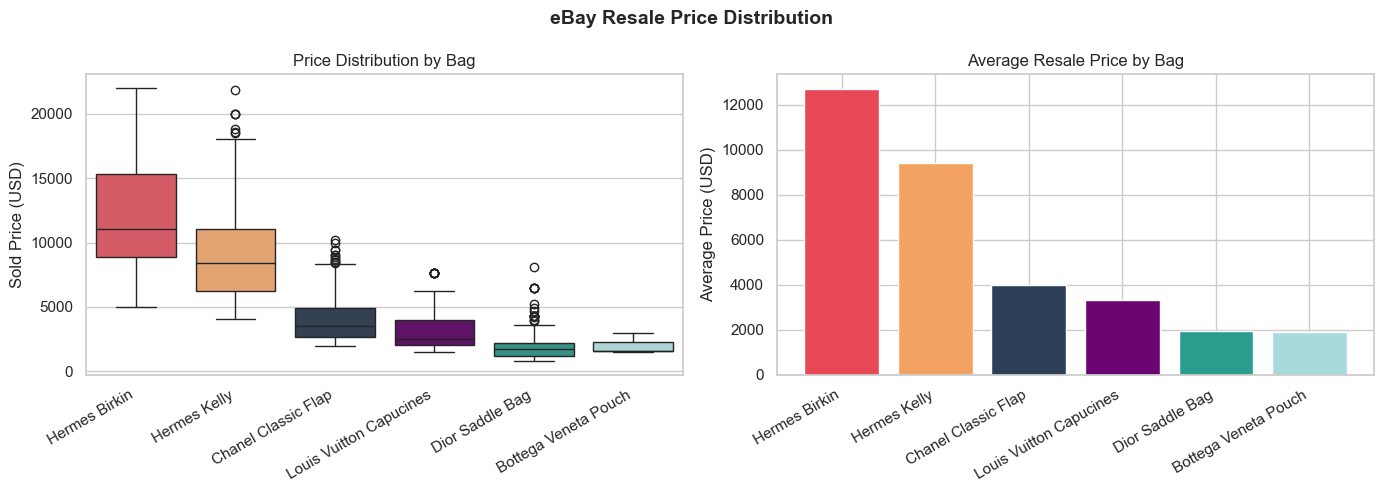

In [16]:
print("\nEBAY RESALE PRICE STATISTICS\n")
print(ebay.groupby('bag_query')['sold_price'].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("eBay Resale Price Distribution", fontsize=14, fontweight='bold')

# Boxplot
ebay_filtered = ebay[ebay['sold_price'] < ebay['sold_price'].quantile(0.99)]
order = ebay_filtered.groupby('bag_query')['sold_price'].median().sort_values(ascending=False).index
sns.boxplot(data=ebay_filtered, x='bag_query', y='sold_price', order=order,
            palette={bag: BAG_COLORS[bag] for bag in order if bag in BAG_COLORS},
            ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_title("Price Distribution by Bag")
axes[0].set_ylabel("Sold Price (USD)")
axes[0].set_xlabel("")

#Barchart
avg_price = ebay.groupby('bag_query')['sold_price'].mean().sort_values(ascending=False)
axes[1].bar(avg_price.index, avg_price.values,
            color=[BAG_COLORS.get(b, '#999999') for b in avg_price.index])
axes[1].set_title("Average Resale Price by Bag")
axes[1].set_ylabel("Average Price (USD)")
axes[1].set_xticklabels(avg_price.index, rotation=30, ha='right')
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

### 2.2.2. Outlier Analysis


 EBAY OUTLIER ANALYSIS 


Total raw listings:      2044
Listings removed:        773 (37.8%)
Listings kept:           1271 (62.2%)

PRICE FLOORS

  Chanel Classic Flap: $2,000
  Hermes Birkin: $5,000
  Hermes Kelly: $4,000
  Dior Saddle Bag: $800
  Bottega Veneta Pouch: $1,500
  Louis Vuitton Capucines: $1,500

REMOVED LISTINGS BY BAG

bag_query
Chanel Classic Flap        252
Bottega Veneta Pouch       234
Dior Saddle Bag            132
Hermes Kelly                94
Louis Vuitton Capucines     41
Hermes Birkin               20

PRICE DISTRIBUTION BEFORE VS AFTER FILTERING

                         Price Floor  Before (mean)  After (mean)  Before (median)  After (median)  Removed (n)
Bottega Veneta Pouch            1500          543.0        1900.0            359.0          1615.0          234
Chanel Classic Flap             2000         2742.0        4004.0           2460.0          3500.0          252
Dior Saddle Bag                  800         1465.0        1944.0           1199.0

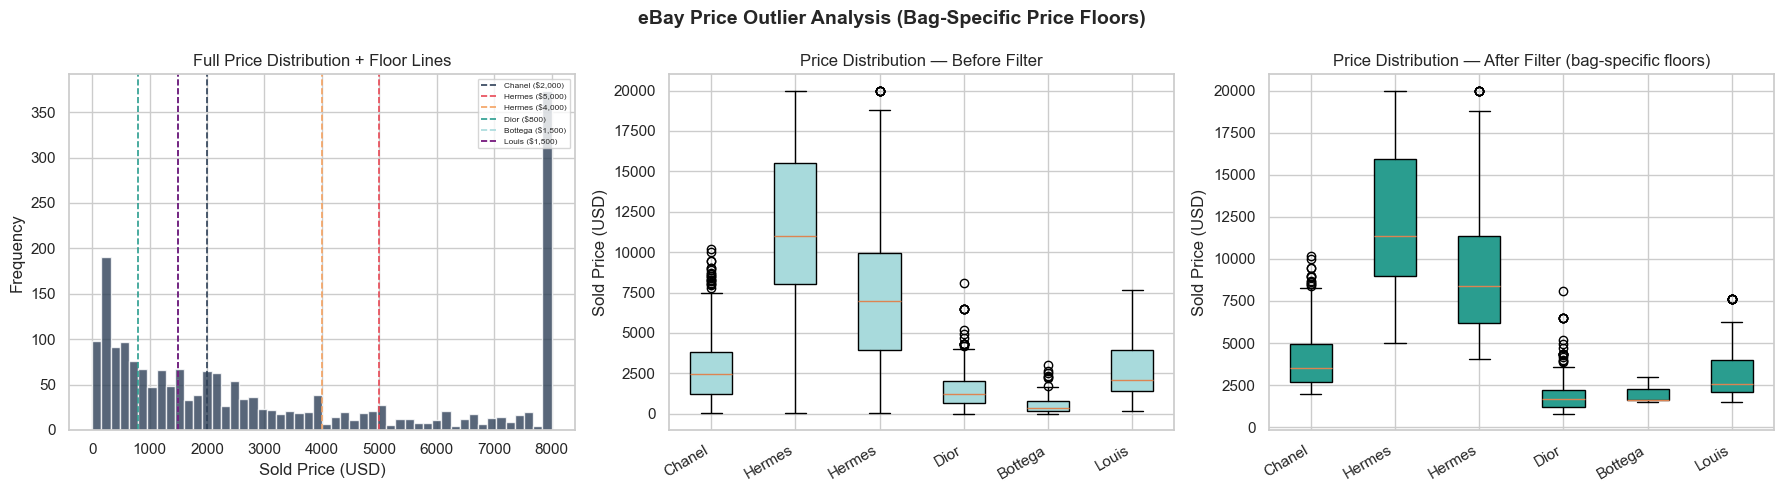

In [17]:
ebay_raw['price_floor'] = ebay_raw['bag_query'].map(bag_price_floors)
ebay_filtered_out         = ebay_raw[ebay_raw['sold_price'] < ebay_raw['price_floor']]
ebay_kept                 = ebay_raw[ebay_raw['sold_price'] >= ebay_raw['price_floor']]

print("\n EBAY OUTLIER ANALYSIS \n")
print(f"\nTotal raw listings:      {len(ebay_raw)}")
print(f"Listings removed:        {len(ebay_filtered_out)} ({len(ebay_filtered_out)/len(ebay_raw)*100:.1f}%)")
print(f"Listings kept:           {len(ebay_kept)} ({len(ebay_kept)/len(ebay_raw)*100:.1f}%)")

print("\nPRICE FLOORS\n")
for bag, floor in bag_price_floors.items():
    print(f"  {bag}: ${floor:,}")

print("\nREMOVED LISTINGS BY BAG\n")
print(ebay_filtered_out['bag_query'].value_counts().to_string())

print("\nPRICE DISTRIBUTION BEFORE VS AFTER FILTERING\n")
comparison = pd.DataFrame({
    'Price Floor':    pd.Series(bag_price_floors),
    'Before (mean)':  ebay_raw.groupby('bag_query')['sold_price'].mean().round(0),
    'After (mean)':   ebay_kept.groupby('bag_query')['sold_price'].mean().round(0),
    'Before (median)':ebay_raw.groupby('bag_query')['sold_price'].median().round(0),
    'After (median)': ebay_kept.groupby('bag_query')['sold_price'].median().round(0),
    'Removed (n)':    ebay_filtered_out.groupby('bag_query').size(),
})
print(comparison.to_string())

# Graphs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("eBay Price Outlier Analysis (Bag-Specific Price Floors)", fontsize=14, fontweight='bold')

# Full distribution histogram
axes[0].hist(ebay_raw['sold_price'].clip(upper=8000), bins=50,
             color='#2E4057', edgecolor='white', alpha=0.8)
for bag, floor in bag_price_floors.items():
    axes[0].axvline(floor, linewidth=1.2, linestyle='--',
                    color=BAG_COLORS[bag], label=f"{bag.split()[0]} (${floor:,})")
axes[0].set_title("Full Price Distribution + Floor Lines")
axes[0].set_xlabel("Sold Price (USD)")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=6)

# Before filter boxplot
data_before = [ebay_raw[ebay_raw['bag_query'] == bag]['sold_price'].clip(upper=20000)
               for bag in BAG_COLORS.keys()]
data_after  = [ebay_kept[ebay_kept['bag_query'] == bag]['sold_price'].clip(upper=20000)
               for bag in BAG_COLORS.keys()]

axes[1].boxplot(data_before, labels=[b.split()[0] for b in BAG_COLORS.keys()],
                patch_artist=True, boxprops=dict(facecolor='#A8DADC'))
axes[1].set_title("Price Distribution — Before Filter")
axes[1].set_xticklabels([b.split()[0] for b in BAG_COLORS.keys()], rotation=30, ha='right')
axes[1].set_ylabel("Sold Price (USD)")

# After filter boxplot
axes[2].boxplot(data_after, labels=[b.split()[0] for b in BAG_COLORS.keys()],
                patch_artist=True, boxprops=dict(facecolor='#2A9D8F'))
axes[2].set_title("Price Distribution — After Filter (bag-specific floors)")
axes[2].set_xticklabels([b.split()[0] for b in BAG_COLORS.keys()], rotation=30, ha='right')
axes[2].set_ylabel("Sold Price (USD)")

plt.tight_layout()
plt.show()

### 2.2.3. Resale Price Over Time

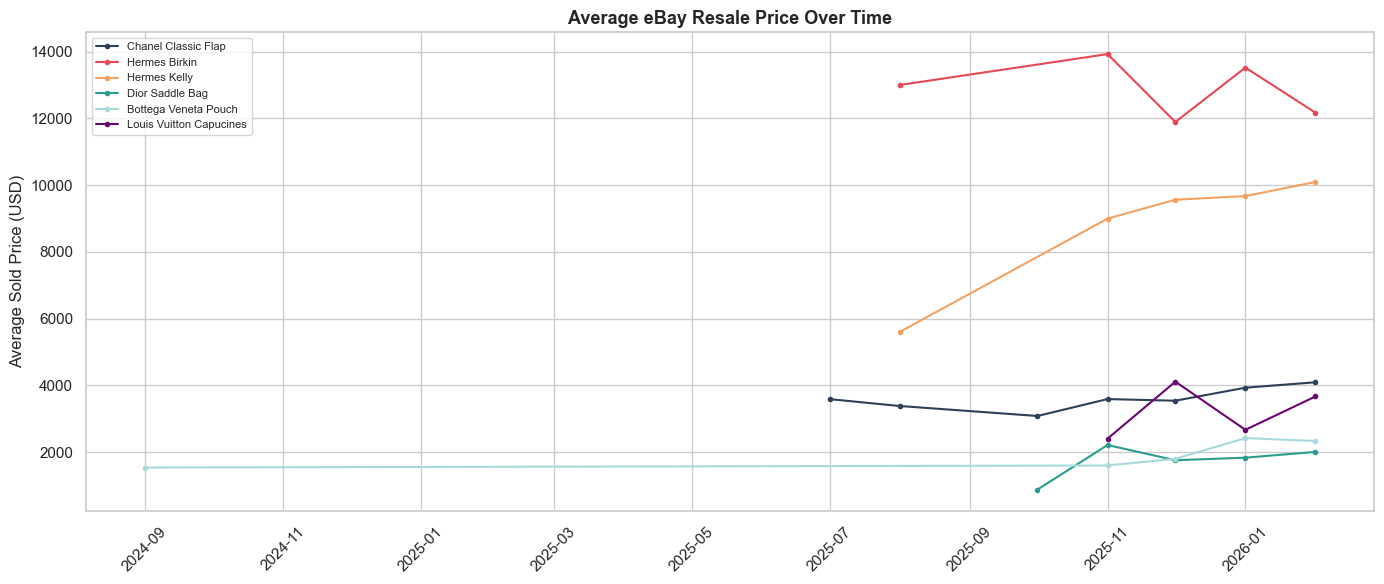

In [18]:
ebay_time = ebay.dropna(subset=['month']).copy()
ebay_monthly = ebay_time.groupby(['month', 'bag_query'])['sold_price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for bag, color in BAG_COLORS.items():
    data = ebay_monthly[ebay_monthly['bag_query'] == bag]
    if len(data) > 0:
        ax.plot(data['month'], data['sold_price'], marker='o', markersize=3,
                label=bag, color=color, linewidth=1.5)

ax.set_title("Average eBay Resale Price Over Time", fontsize=13, fontweight='bold')
ax.set_ylabel("Average Sold Price (USD)")
ax.set_xlabel("")
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2.3. Google Trends

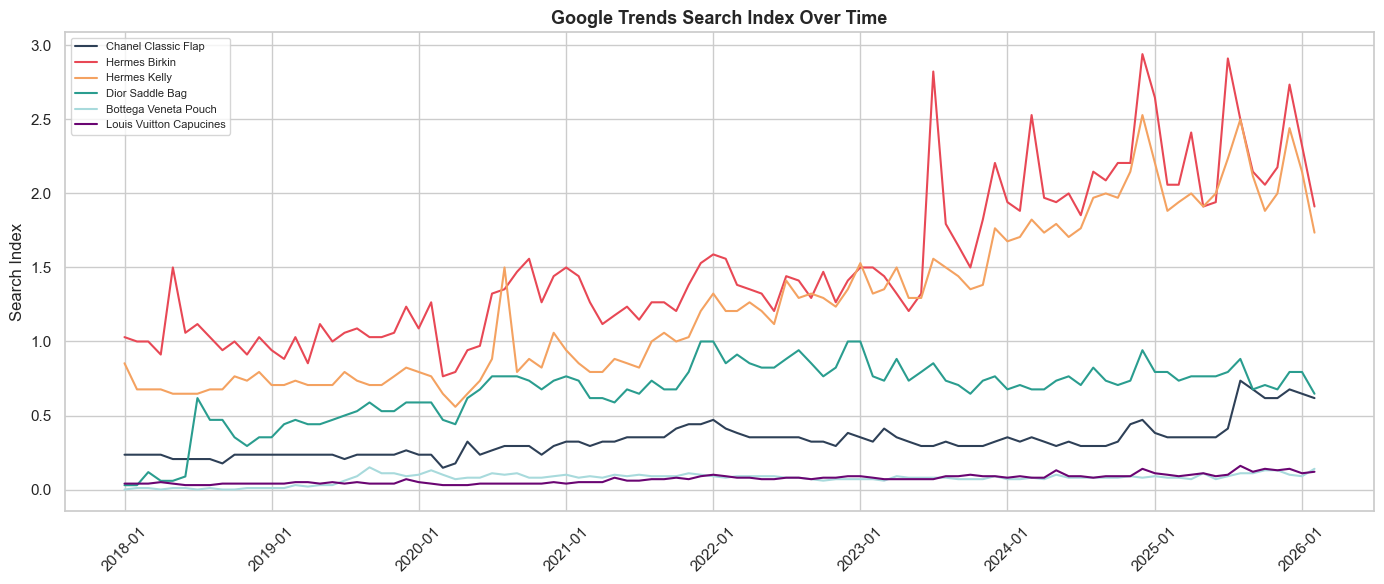

Saved: plot3_google_trends.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
for bag, color in BAG_COLORS.items():
    data = google[google['bag_query'] == bag]
    ax.plot(data['month'], data['search_index'], label=bag, color=color, linewidth=1.5)

ax.set_title("Google Trends Search Index Over Time", fontsize=13, fontweight='bold')
ax.set_ylabel("Search Index")
ax.set_xlabel("")
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Saved: plot3_google_trends.png")

## 2.4. Social Media Engagement Metrics

### 2.4.1. Average Engagement

In [20]:
# Convert numeric columns to proper types
youtube['view_count']    = pd.to_numeric(youtube['view_count'],    errors='coerce')
youtube['like_count']    = pd.to_numeric(youtube['like_count'],    errors='coerce')
youtube['comment_count'] = pd.to_numeric(youtube['comment_count'], errors='coerce')

tiktok['playCount']  = pd.to_numeric(tiktok['playCount'],  errors='coerce')
tiktok['diggCount']  = pd.to_numeric(tiktok['diggCount'],  errors='coerce')
tiktok['shareCount'] = pd.to_numeric(tiktok['shareCount'], errors='coerce')

instagram['likesCount']    = pd.to_numeric(instagram['likesCount'],    errors='coerce')
instagram['commentsCount'] = pd.to_numeric(instagram['commentsCount'], errors='coerce')


SOCIAL MEDIA ENGAGEMENT SUMMARY


YouTube — avg views/likes/comments per bag:
                         view_count  like_count  comment_count
bag_query                                                     
2026-03-04                  13307.0       236.0            NaN
Bottega Veneta Pouch       596505.0      4493.0           91.0
Chanel Classic Flap        160782.0      4554.0          169.0
Dior Saddle Bag             76749.0      2896.0           75.0
Hermes Birkin             2040677.0     20367.0          646.0
Hermes Kelly               113211.0      3186.0           90.0
Louis Vuitton Capucines    218388.0      5666.0           83.0

TikTok — avg plays/likes/shares per bag:
                         playCount  diggCount  shareCount
bag_query                                                
Bottega Veneta Pouch      178076.0    16318.0      1444.0
Chanel Classic Flap       407385.0    22141.0      1365.0
Dior Saddle Bag           272837.0    15700.0      1067.0
Hermes Birkin         

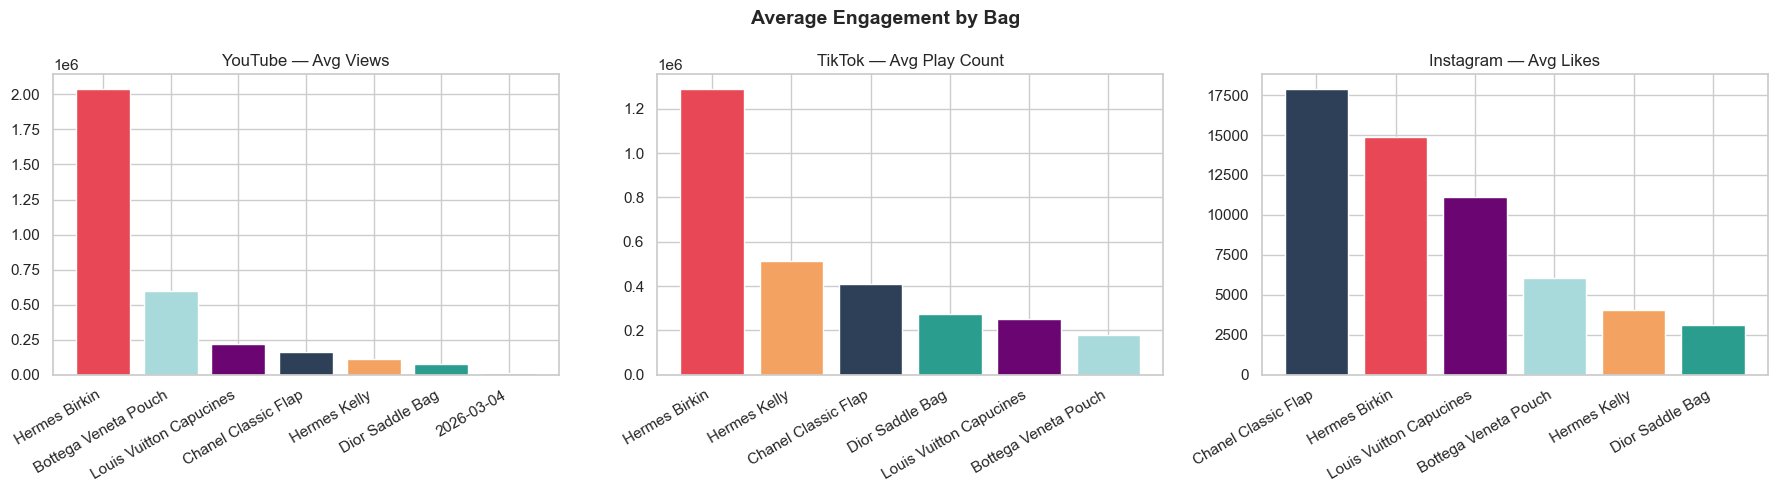

In [21]:

print("\nSOCIAL MEDIA ENGAGEMENT SUMMARY\n")


print("\nYouTube — avg views/likes/comments per bag:")
print(youtube.groupby('bag_query')[['view_count', 'like_count', 'comment_count']].mean().round(0))

print("\nTikTok — avg plays/likes/shares per bag:")
print(tiktok.groupby('bag_query')[['playCount', 'diggCount', 'shareCount']].mean().round(0))

print("\nInstagram — avg likes/comments per bag:")
ig_valid = instagram[instagram['likesCount'] >= 0]
print(ig_valid.groupby('bag_query')[['likesCount', 'commentsCount']].mean().round(0))

# Engagement bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Average Engagement by Bag", fontsize=14, fontweight='bold')

yt_avg = youtube.groupby('bag_query')['view_count'].mean().sort_values(ascending=False)
axes[0].bar(yt_avg.index, yt_avg.values, color=[BAG_COLORS.get(b, '#999999') for b in yt_avg.index])
axes[0].set_title("YouTube — Avg Views")
axes[0].set_xticklabels(yt_avg.index, rotation=30, ha='right')
axes[0].set_xlabel("")

tt_avg = tiktok.groupby('bag_query')['playCount'].mean().sort_values(ascending=False)
axes[1].bar(tt_avg.index, tt_avg.values, color=[BAG_COLORS.get(b, '#999999') for b in tt_avg.index])
axes[1].set_title("TikTok — Avg Play Count")
axes[1].set_xticklabels(tt_avg.index, rotation=30, ha='right')
axes[1].set_xlabel("")

ig_avg = ig_valid.groupby('bag_query')['likesCount'].mean().sort_values(ascending=False)
axes[2].bar(ig_avg.index, ig_avg.values, color=[BAG_COLORS.get(b, '#999999') for b in ig_avg.index])
axes[2].set_title("Instagram — Avg Likes")
axes[2].set_xticklabels(ig_avg.index, rotation=30, ha='right')
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

### 2.4.2. Monthly Mention Volume

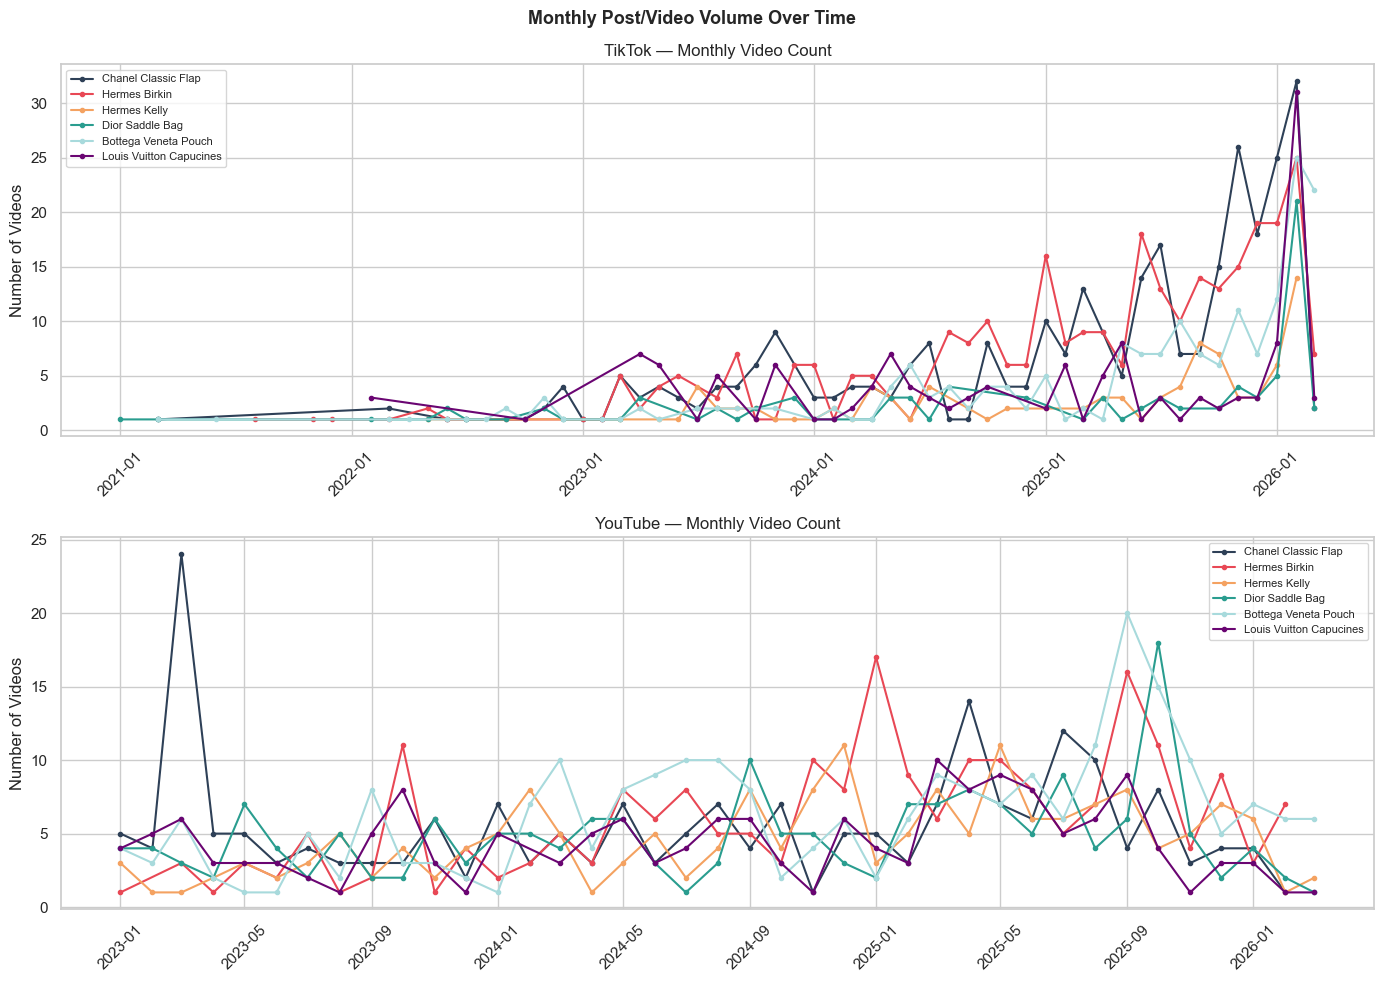

Saved: plot5_monthly_volume.png


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Monthly Post/Video Volume Over Time", fontsize=13, fontweight='bold')

# TikTok monthly post count
tt_monthly = tiktok.groupby(['month', 'bag_query']).size().reset_index(name='post_count')
for bag, color in BAG_COLORS.items():
    data = tt_monthly[tt_monthly['bag_query'] == bag]
    if len(data) > 0:
        axes[0].plot(data['month'], data['post_count'], marker='o', markersize=3,
                     label=bag, color=color, linewidth=1.5)
axes[0].set_title("TikTok — Monthly Video Count")
axes[0].set_ylabel("Number of Videos")
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# YouTube monthly video count
yt_monthly = youtube.groupby(['month', 'bag_query']).size().reset_index(name='video_count')
for bag, color in BAG_COLORS.items():
    data = yt_monthly[yt_monthly['bag_query'] == bag]
    if len(data) > 0:
        axes[1].plot(data['month'], data['video_count'], marker='o', markersize=3,
                     label=bag, color=color, linewidth=1.5)
axes[1].set_title("YouTube — Monthly Video Count")
axes[1].set_ylabel("Number of Videos")
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()
print("Saved: plot5_monthly_volume.png")

## 2.5. Correlation between Google Trends and Resale Price


 CORRELATION: GOOGLE TRENDS vs EBAY RESALE PRICE


Merged rows: 31

Correlation per bag (Google Search Index vs Resale Price):
  Chanel Classic Flap: r = -0.084
  Hermes Birkin: r = -0.229
  Hermes Kelly: r = -0.635
  Dior Saddle Bag: r = -0.142
  Bottega Veneta Pouch: r = 0.206
  Louis Vuitton Capucines: r = 0.489


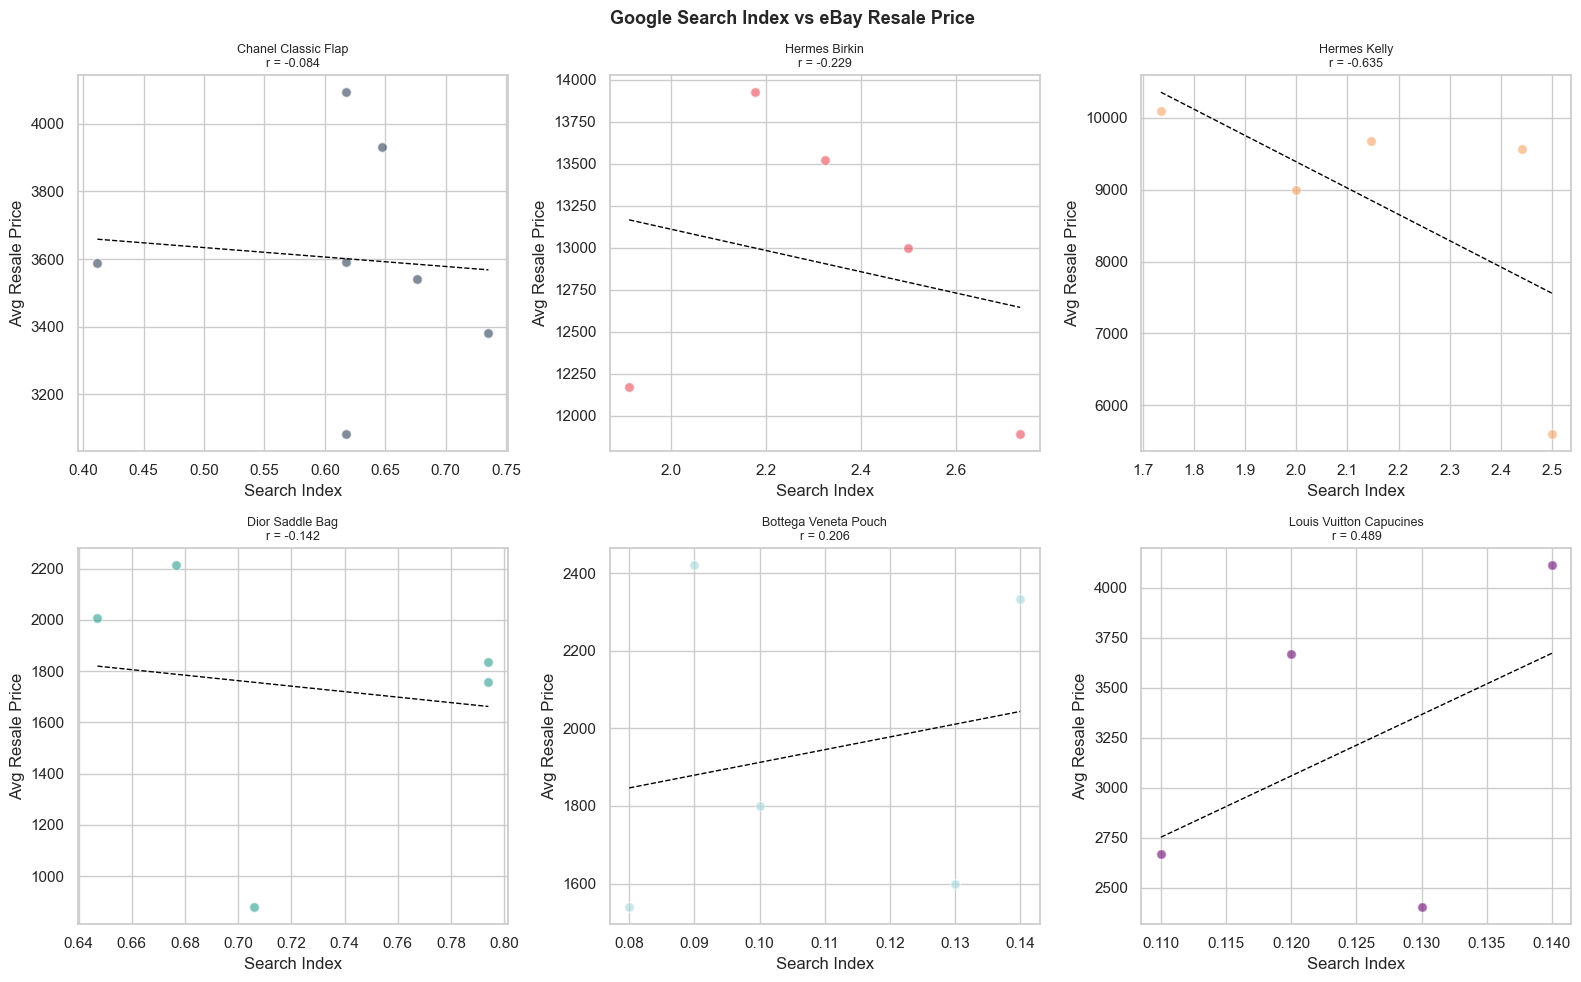

Saved: plot6_correlation_google_ebay.png


In [23]:
print("\n CORRELATION: GOOGLE TRENDS vs EBAY RESALE PRICE\n")

ebay_monthly_avg = ebay_time.groupby(['month', 'bag_query'])['sold_price'].mean().reset_index()
merged = pd.merge(google, ebay_monthly_avg, on=['month', 'bag_query'], how='inner')

print(f"\nMerged rows: {len(merged)}")
print("\nCorrelation per bag (Google Search Index vs Resale Price):")
for bag in merged['bag_query'].unique():
    data = merged[merged['bag_query'] == bag]
    if len(data) > 2:
        corr = data['search_index'].corr(data['sold_price'])
        print(f"  {bag}: r = {corr:.3f}")

# Scatter plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Google Search Index vs eBay Resale Price", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, bag in enumerate(BAG_COLORS.keys()):
    data = merged[merged['bag_query'] == bag]
    if len(data) > 2:
        axes[i].scatter(data['search_index'], data['sold_price'],
                        color=COLORS[i], alpha=0.6, edgecolors='white', s=50)
        # Trend line
        z = np.polyfit(data['search_index'], data['sold_price'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['search_index'].min(), data['search_index'].max(), 100)
        axes[i].plot(x_line, p(x_line), color='black', linewidth=1, linestyle='--')
        corr = data['search_index'].corr(data['sold_price'])
        axes[i].set_title(f"{bag}\nr = {corr:.3f}", fontsize=9)
        axes[i].set_xlabel("Search Index")
        axes[i].set_ylabel("Avg Resale Price")
    else:
        axes[i].set_title(f"{bag}\n(insufficient data)")

plt.tight_layout()
plt.show()
print("Saved: plot6_correlation_google_ebay.png")

## 2.6. Heatmap


 CROSS-PLATFORM NORMALIZED ENGAGEMENT HEATMAP



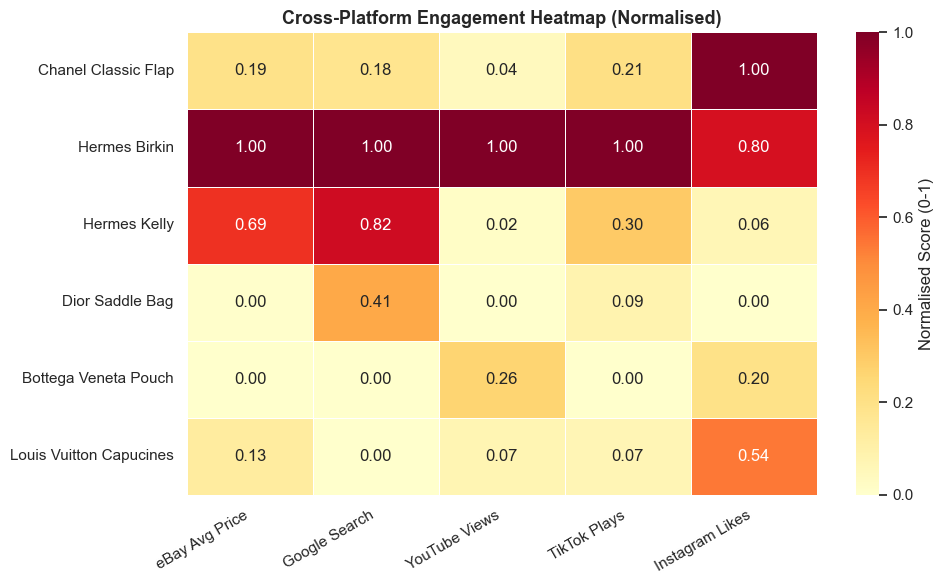

In [24]:

print("\n CROSS-PLATFORM NORMALIZED ENGAGEMENT HEATMAP\n")


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

platform_df = pd.DataFrame(index=list(BAG_COLORS.keys()))
platform_df['eBay Avg Price']     = ebay.groupby('bag_query')['sold_price'].mean()
platform_df['Google Search']      = google.groupby('bag_query')['search_index'].mean()
platform_df['YouTube Views']      = youtube.groupby('bag_query')['view_count'].mean()
platform_df['TikTok Plays']       = tiktok.groupby('bag_query')['playCount'].mean()
platform_df['Instagram Likes']    = ig_valid.groupby('bag_query')['likesCount'].mean()

platform_df_scaled = pd.DataFrame(
    scaler.fit_transform(platform_df.fillna(0)),
    index=platform_df.index,
    columns=platform_df.columns
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(platform_df_scaled, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised Score (0-1)'})
ax.set_title("Cross-Platform Engagement Heatmap (Normalised)", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


# 3. Feature Engieering

## 3.1. Derived Features

### 3.1.1. Weekly Dataset Pre-Check

In [25]:
df_weekly['week'] = pd.to_datetime(df_weekly['week'])

df_model_weekly = df_weekly.dropna(subset=['avg_resale_price']).copy()

feature_cols = ['search_index', 'yt_total_views', 'tt_total_plays',
                'ig_total_likes', 'search_index_lag1', 'tt_total_plays_lag1',
                'yt_total_views_lag1', 'ig_total_likes_lag1']

print(f"Model-ready rows: {len(df_model_weekly)}")
print(f"\nNull counts in features:")
print(df_model_weekly[feature_cols].isnull().sum())
print(f"\nComplete rows (no nulls): {df_model_weekly[feature_cols + ['avg_resale_price']].dropna().shape[0]}")
print(f"\nRows per bag:")
print(df_model_weekly['bag_query'].value_counts())

Model-ready rows: 80

Null counts in features:
search_index           0
yt_total_views         0
tt_total_plays         0
ig_total_likes         0
search_index_lag1      0
tt_total_plays_lag1    0
yt_total_views_lag1    0
ig_total_likes_lag1    0
dtype: int64

Complete rows (no nulls): 80

Rows per bag:
bag_query
Dior Saddle Bag            15
Chanel Classic Flap        14
Hermes Birkin              14
Hermes Kelly               14
Louis Vuitton Capucines    13
Bottega Veneta Pouch       10
Name: count, dtype: int64


In [26]:
print(" DATASET HEALTH CHECK \n")
print(f"\nShape: {df_weekly.shape}")
print(f"Bags: {df_weekly['bag_query'].nunique()} | Weeks: {df_weekly['week'].nunique()}")
print(f"Date range: {df_weekly['week'].min()} → {df_weekly['week'].max()}")

print(f"\n - Rows per bag \n")
print(df_weekly['bag_query'].value_counts())

print(f"\n - Price data coverage per bag \n")
print(df_weekly.groupby('bag_query')['avg_resale_price'].agg(
    available=lambda x: x.notna().sum(),
    missing=lambda x: x.isna().sum(),
    avg_price='mean'
).round(0))

print(f"\n - Search index coverage \n")
print(df_weekly.groupby('bag_query')['search_index'].agg(
    available=lambda x: x.notna().sum(),
    missing=lambda x: x.isna().sum(),
    avg_index='mean'
).round(3))

print(f"\n - Date range per bag \n")
print(df_weekly.groupby('bag_query')['week'].agg(['min', 'max', 'count']))

print(f"\n - Resale premium sanity check \n")
print(df_model_weekly.groupby('bag_query')[['avg_resale_price', 'retail_price', 'resale_premium']].mean().round(3))

 DATASET HEALTH CHECK 


Shape: (858, 22)
Bags: 6 | Weeks: 166
Date range: 2023-01-02 00:00:00 → 2026-03-02 00:00:00

 - Rows per bag 

bag_query
Chanel Classic Flap        153
Hermes Birkin              148
Hermes Kelly               143
Bottega Veneta Pouch       142
Louis Vuitton Capucines    138
Dior Saddle Bag            134
Name: count, dtype: int64

 - Price data coverage per bag 

                         available  missing  avg_price
bag_query                                             
Bottega Veneta Pouch            10      132     2022.0
Chanel Classic Flap             14      139     3744.0
Dior Saddle Bag                 15      119     1802.0
Hermes Birkin                   14      134    12666.0
Hermes Kelly                    14      129     9435.0
Louis Vuitton Capucines         13      125     3305.0

 - Search index coverage 

                         available  missing  avg_index
bag_query                                             
Bottega Veneta Pouch          

### 3.1.2. Popularity Score

In [27]:
weights = {
    'search_index':   0.30,
    'tt_total_plays': 0.25,
    'yt_total_views': 0.20,
    'ig_total_likes': 0.15,
    'sales_volume':   0.10,
}

pop_cols = list(weights.keys())
df_weekly[pop_cols] = df_weekly[pop_cols].fillna(0)

# ── Normalise within each bag (0-1 relative to that bag's own min/max) ────────
for col in pop_cols:
    col_min = df_weekly.groupby('bag_query')[col].transform('min')
    col_max = df_weekly.groupby('bag_query')[col].transform('max')
    df_weekly[f'{col}_norm'] = (df_weekly[col] - col_min) / (col_max - col_min + 1e-9)

# ── Weighted score ────────────────────────────────────────────────────────────
df_weekly['popularity_score'] = sum(
    weights[col] * df_weekly[f'{col}_norm'] for col in pop_cols
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nAVG POPULARITY SCORE PER BAG\n")
print(df_weekly.groupby('bag_query')['popularity_score'].mean().sort_values(ascending=False).round(3))

print("\nLATEST WEEK POPULARITY RANKING \n")
latest = df_weekly[df_weekly['week'] == df_weekly['week'].max()]
print(latest[['bag_query', 'popularity_score'] + [f'{c}_norm' for c in pop_cols]]
      .sort_values('popularity_score', ascending=False)
      .round(4)
      .to_string(index=False))


AVG POPULARITY SCORE PER BAG

bag_query
Hermes Kelly               0.219
Hermes Birkin              0.216
Dior Saddle Bag            0.144
Chanel Classic Flap        0.112
Bottega Veneta Pouch       0.062
Louis Vuitton Capucines    0.048
Name: popularity_score, dtype: float64

LATEST WEEK POPULARITY RANKING 

              bag_query  popularity_score  search_index_norm  tt_total_plays_norm  yt_total_views_norm  ig_total_likes_norm  sales_volume_norm
           Hermes Kelly            0.2908             0.5781               0.0847               0.0058               0.6334                0.0
    Chanel Classic Flap            0.2291             0.7333               0.0000               0.0001               0.0605                0.0
          Hermes Birkin            0.1661             0.5513               0.0021               0.0000               0.0010                0.0
   Bottega Veneta Pouch            0.0557             0.1363               0.0111               0.0004              

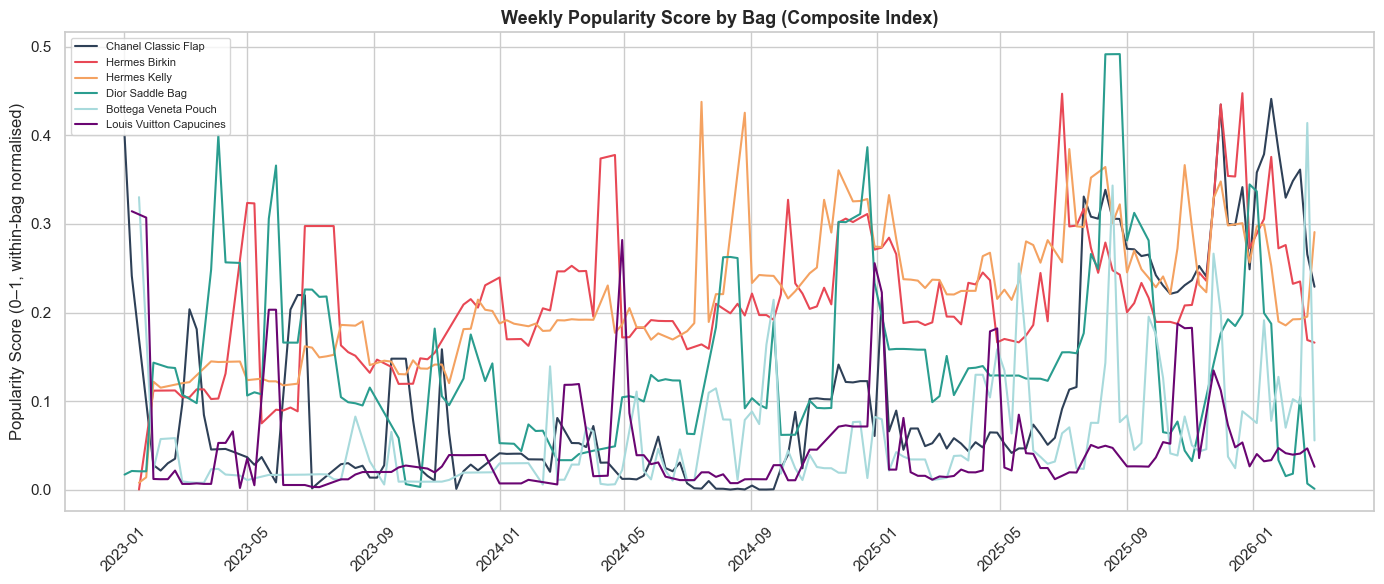

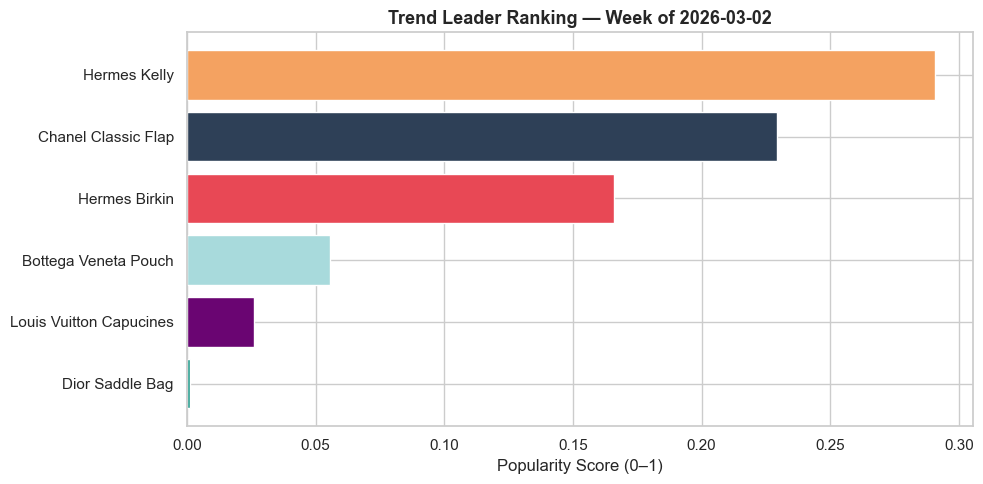

In [28]:
# Popularity Score over Time
fig, ax = plt.subplots(figsize=(14, 6))
for bag, color in BAG_COLORS.items():
    data = df_weekly[df_weekly['bag_query'] == bag]
    ax.plot(data['week'], data['popularity_score'], label=bag, color=color, linewidth=1.5)

ax.set_title("Weekly Popularity Score by Bag (Composite Index)", fontsize=13, fontweight='bold')
ax.set_ylabel("Popularity Score (0–1, within-bag normalised)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Latest Week Ranking
fig, ax = plt.subplots(figsize=(10, 5))
latest_sorted = latest.sort_values('popularity_score', ascending=True)
bar_colors = [BAG_COLORS[b] for b in latest_sorted['bag_query']]
ax.barh(latest_sorted['bag_query'], latest_sorted['popularity_score'], color=bar_colors)
ax.set_title(f"Trend Leader Ranking — Week of {df_weekly['week'].max().strftime('%Y-%m-%d')}",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Popularity Score (0–1)")
plt.tight_layout()
plt.show()

### 3.2.3. Sensitivity Analysis


 AVG POPULARITY SCORES UNDER EACH SCENARIO 

                         Chosen Weights (correlation-based)  Equal Weights  Search Dominant  Social Dominant  Rank (Chosen)
bag_query                                                                                                                  
Bottega Veneta Pouch                                  0.062          0.057            0.060            0.066              5
Chanel Classic Flap                                   0.112          0.088            0.155            0.069              4
Dior Saddle Bag                                       0.144          0.108            0.205            0.081              3
Hermes Birkin                                         0.216          0.157            0.331            0.096              2
Hermes Kelly                                          0.219          0.157            0.338            0.102              1
Louis Vuitton Capucines                               0.048          0.042            

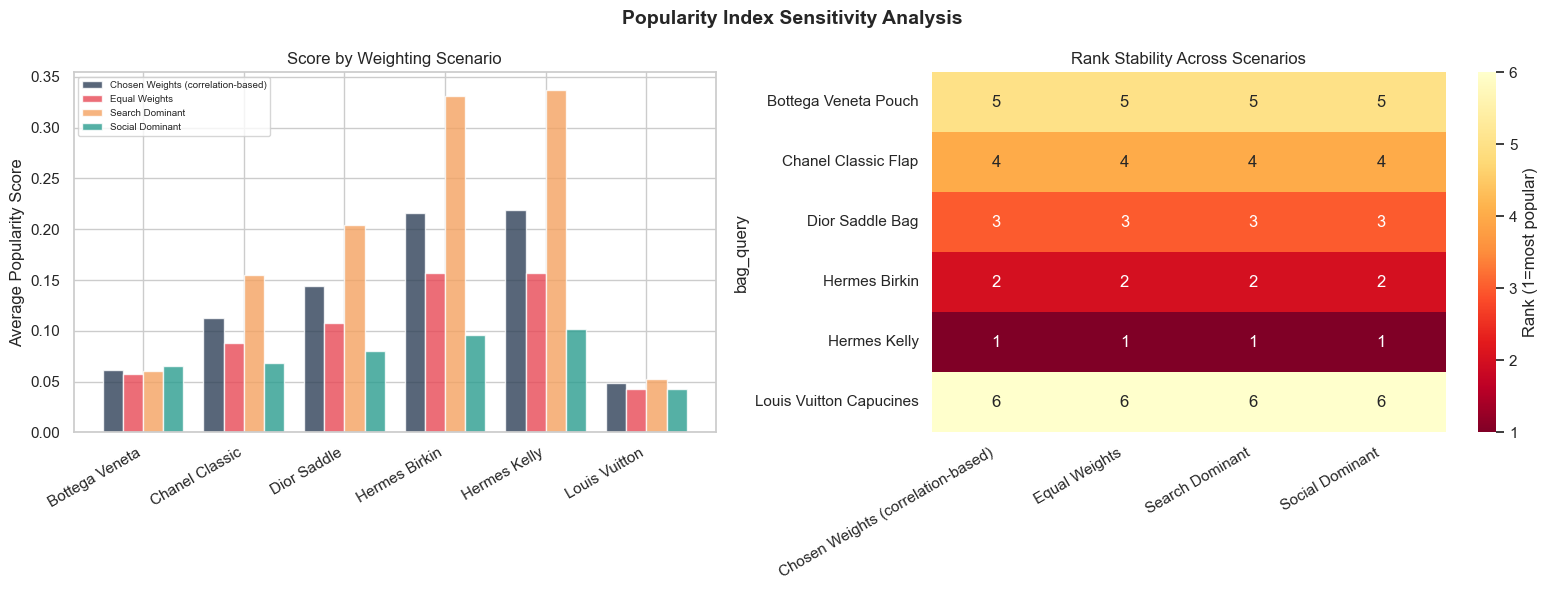

In [29]:

weight_scenarios = {
    'Chosen Weights (correlation-based)': {
        'search_index': 0.30, 'tt_total_plays': 0.25,
        'yt_total_views': 0.20, 'ig_total_likes': 0.15, 'sales_volume': 0.10
    },
    'Equal Weights': {
        'search_index': 0.20, 'tt_total_plays': 0.20,
        'yt_total_views': 0.20, 'ig_total_likes': 0.20, 'sales_volume': 0.20
    },
    'Search Dominant': {
        'search_index': 0.50, 'tt_total_plays': 0.15,
        'yt_total_views': 0.15, 'ig_total_likes': 0.15, 'sales_volume': 0.05
    },
    'Social Dominant': {
        'search_index': 0.10, 'tt_total_plays': 0.30,
        'yt_total_views': 0.25, 'ig_total_likes': 0.25, 'sales_volume': 0.10
    },
}

pop_cols = ['search_index', 'tt_total_plays', 'yt_total_views', 'ig_total_likes', 'sales_volume']
df_weekly[pop_cols] = df_weekly[pop_cols].fillna(0)

scenario_scores = {}

for scenario_name, weights in weight_scenarios.items():
    df_temp = df_weekly.copy()
    for col in pop_cols:
        col_min = df_temp.groupby('bag_query')[col].transform('min')
        col_max = df_temp.groupby('bag_query')[col].transform('max')
        df_temp[f'{col}_norm'] = (df_temp[col] - col_min) / (col_max - col_min + 1e-9)

    df_temp['score'] = sum(weights[col] * df_temp[f'{col}_norm'] for col in pop_cols)
    scenario_scores[scenario_name] = df_temp.groupby('bag_query')['score'].mean()

# Comparison table 
scores_df = pd.DataFrame(scenario_scores)
scores_df['Rank (Chosen)'] = scores_df['Chosen Weights (correlation-based)'].rank(ascending=False).astype(int)

print("\n AVG POPULARITY SCORES UNDER EACH SCENARIO \n")
print(scores_df.round(3).to_string())

# Check if rankings change across scenarios
print("\n RANKING STABILITY \n")
for scenario in weight_scenarios.keys():
    ranks = scores_df[scenario].rank(ascending=False).astype(int)
    print(f"\n{scenario}:")
    for bag in ranks.index:
        print(f"  {bag}: Rank {ranks[bag]}")

print("\n CORRELATION BETWEEN SCENARIOS \n")
print(scores_df.corr().round(3).to_string())

#  Plot 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Popularity Index Sensitivity Analysis", fontsize=14, fontweight='bold')

# Bar chart comparison
x     = np.arange(len(scores_df))
width = 0.2
scenario_colors = ['#2E4057', '#E84855', '#F4A261', '#2A9D8F']

for i, (scenario, color) in enumerate(zip(weight_scenarios.keys(), scenario_colors)):
    axes[0].bar(x + i * width, scores_df[scenario],
                width, label=scenario, color=color, alpha=0.8)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels([b.split()[0] + ' ' + b.split()[1] 
                          for b in scores_df.index], rotation=30, ha='right')
axes[0].set_ylabel("Average Popularity Score")
axes[0].set_title("Score by Weighting Scenario")
axes[0].legend(fontsize=7)

# Rank stability heatmap
rank_df = pd.DataFrame({
    s: scores_df[s].rank(ascending=False).astype(int)
    for s in weight_scenarios.keys()
})
sns.heatmap(rank_df, annot=True, fmt='d', cmap='YlOrRd_r',
            ax=axes[1], cbar_kws={'label': 'Rank (1=most popular)'})
axes[1].set_title("Rank Stability Across Scenarios")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# 4. Modelling

## 4.1. Feature Set Up

In [30]:
feature_cols = ['search_index_lag1', 'tt_total_plays_lag1', 'ig_total_likes_lag1']

target = 'popularity_score'

df_model_pop = df_weekly.dropna(subset=feature_cols + [target]).copy()

X = df_model_pop[feature_cols]
y = df_model_pop[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Model dataset: {len(df_model_pop)} rows, {len(feature_cols)} features")

Model dataset: 858 rows, 3 features


## 4.2. Models

### 4.2.1. Linear Regression

In [31]:
lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred_lr = lr.predict(X_scaled)

print("Linear Regression \n")
print(f"R²:   {r2_score(y, y_pred_lr):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred_lr)):.4f}")

Linear Regression 

R²:   0.538
RMSE: 0.0732


### 4.2.2. Random Forest

In [32]:
rf = RandomForestRegressor(n_estimators=100, max_depth=3,
                           min_samples_leaf=5, random_state=42)
rf.fit(X_scaled, y)
y_pred_rf = rf.predict(X_scaled)

print("\n Random Forest \n")
print(f"R²:   {r2_score(y, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred_rf)):.4f}")
print("\nFeature importances:\n")
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
print(imp_df.sort_values('importance', ascending=False).to_string(index=False))


 Random Forest 

R²:   0.655
RMSE: 0.0632

Feature importances:

            feature  importance
  search_index_lag1    0.863724
ig_total_likes_lag1    0.115461
tt_total_plays_lag1    0.020815


## 4.3. Validation

### 4.3.1. 5-Fold CV

In [33]:
print("\n 5-Fold Cross-Validation \n")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(LinearRegression(), X_scaled, y, cv=kf, scoring='r2')
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=3,
                         min_samples_leaf=5, random_state=42),
                         X_scaled, y, cv=kf, scoring='r2')
print(f"Linear Regression: R² = {lr_cv.mean():.3f} (±{lr_cv.std():.3f})")
print(f"Random Forest:     R² = {rf_cv.mean():.3f} (±{rf_cv.std():.3f})")


 5-Fold Cross-Validation 

Linear Regression: R² = 0.514 (±0.093)
Random Forest:     R² = 0.609 (±0.076)


### 4.3.2. Temporal Train/Test Split

In [34]:


print("TEMPORAL TRAIN/TEST SPLIT VALIDATION\n")

sorted_weeks = sorted(df_model_pop['week'].unique())
split_idx    = int(len(sorted_weeks) * 0.8)
split_week   = sorted_weeks[split_idx]

train = df_model_pop[df_model_pop['week'] <  split_week].copy()
test  = df_model_pop[df_model_pop['week'] >= split_week].copy()

print(f"Train: {len(train)} rows | {train['week'].min().strftime('%Y-%m-%d')} → {train['week'].max().strftime('%Y-%m-%d')}")
print(f"Test:  {len(test)} rows  | {test['week'].min().strftime('%Y-%m-%d')} → {test['week'].max().strftime('%Y-%m-%d')}")
print(f"Split week: {split_week.strftime('%Y-%m-%d')}")

X_train = train[feature_cols]
y_train = train['popularity_score']
X_test  = test[feature_cols]
y_test  = test['popularity_score']

scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train)
X_test_scaled  = scaler_temp.transform(X_test)

# LR
lr_temp = LinearRegression()
lr_temp.fit(X_train_scaled, y_train)
lr_test_pred = lr_temp.predict(X_test_scaled)

print("\n=== Linear Regression — Temporal Split ===")
print(f"Train R²: {r2_score(y_train, lr_temp.predict(X_train_scaled)):.3f}")
print(f"Test  R²: {r2_score(y_test,  lr_test_pred):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")

# RF
rf_temp = RandomForestRegressor(n_estimators=100, max_depth=3,
                                min_samples_leaf=5, random_state=42)
rf_temp.fit(X_train_scaled, y_train)
rf_test_pred = rf_temp.predict(X_test_scaled)

print("\n=== Random Forest — Temporal Split ===")
print(f"Train R²: {r2_score(y_train, rf_temp.predict(X_train_scaled)):.3f}")
print(f"Test  R²: {r2_score(y_test,  rf_test_pred):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, rf_test_pred)):.4f}")

TEMPORAL TRAIN/TEST SPLIT VALIDATION

Train: 662 rows | 2023-01-02 → 2025-07-07
Test:  196 rows  | 2025-07-14 → 2026-03-02
Split week: 2025-07-14

=== Linear Regression — Temporal Split ===
Train R²: 0.607
Test  R²: 0.114
Test RMSE: 0.1119

=== Random Forest — Temporal Split ===
Train R²: 0.686
Test  R²: 0.103
Test RMSE: 0.1126


In [35]:
print("THREE-TIER VALIDATION COMPARISON TABLE\n")
print(f"{'Validation Method':<35} {'LR R²':>8} {'RF R²':>8} {'LR RMSE':>10} {'RF RMSE':>10}")
print("-" * 75)
print(f"{'In-sample (full dataset)':<35} {r2_score(y, y_pred_lr):>8.3f} {r2_score(y, y_pred_rf):>8.3f} {np.sqrt(mean_squared_error(y, y_pred_lr)):>10.4f} {np.sqrt(mean_squared_error(y, y_pred_rf)):>10.4f}")
print(f"{'5-Fold CV (random split)':<35} {lr_cv.mean():>8.3f} {rf_cv.mean():>8.3f} {'—':>10} {'—':>10}")
print(f"{'Temporal split (test set)':<35} {r2_score(y_test, lr_test_pred):>8.3f} {r2_score(y_test, rf_test_pred):>8.3f} {np.sqrt(mean_squared_error(y_test, lr_test_pred)):>10.4f} {np.sqrt(mean_squared_error(y_test, rf_test_pred)):>10.4f}")
print("-" * 75)
print(f"\nTrain period: {df_model_pop[df_model_pop['week'] < split_week]['week'].min().strftime('%Y-%m-%d')} → {df_model_pop[df_model_pop['week'] < split_week]['week'].max().strftime('%Y-%m-%d')}")
print(f"Test period:  {df_model_pop[df_model_pop['week'] >= split_week]['week'].min().strftime('%Y-%m-%d')} → {df_model_pop[df_model_pop['week'] >= split_week]['week'].max().strftime('%Y-%m-%d')}")

THREE-TIER VALIDATION COMPARISON TABLE

Validation Method                      LR R²    RF R²    LR RMSE    RF RMSE
---------------------------------------------------------------------------
In-sample (full dataset)               0.538    0.655     0.0732     0.0632
5-Fold CV (random split)               0.514    0.609          —          —
Temporal split (test set)              0.114    0.103     0.1119     0.1126
---------------------------------------------------------------------------

Train period: 2023-01-02 → 2025-07-07
Test period:  2025-07-14 → 2026-03-02


## 4.4. Per-Bag Model Performance

In [36]:
print(" PER-BAG MODEL PERFORMANCE TABLE \n")
print(f"{'Bag':<25} {'n':>6} {'R²':>8} {'RMSE':>10} {'Performance'}")
print("-" * 65)

per_bag_results = []
for bag in sorted(df_model_pop['bag_query'].unique()):
    mask = df_model_pop['bag_query'] == bag
    if mask.sum() > 2:
        r2   = r2_score(y[mask], y_pred_rf[mask])
        rmse = np.sqrt(mean_squared_error(y[mask], y_pred_rf[mask]))
        n    = mask.sum()
        perf = 'Strong' if r2 >= 0.6 else ('Moderate' if r2 >= 0.3 else 'Weak')
        per_bag_results.append({'Bag': bag, 'n': n, 'R²': round(r2,3), 'RMSE': round(rmse,4), 'Performance': perf})
        print(f"  {bag:<25} {n:>6} {r2:>8.3f} {rmse:>10.4f} {perf}")

print("-" * 65)
per_bag_df = pd.DataFrame(per_bag_results).sort_values('R²', ascending=False)
print(f"\nMean R²: {per_bag_df['R²'].mean():.3f}")
print(f"Best:    {per_bag_df.iloc[0]['Bag']} (R²={per_bag_df.iloc[0]['R²']})")
print(f"Worst:   {per_bag_df.iloc[-1]['Bag']} (R²={per_bag_df.iloc[-1]['R²']})")

 PER-BAG MODEL PERFORMANCE TABLE 

Bag                            n       R²       RMSE Performance
-----------------------------------------------------------------
  Bottega Veneta Pouch         142    0.204     0.0616 Weak
  Chanel Classic Flap          153    0.729     0.0603 Strong
  Dior Saddle Bag              134    0.111     0.0908 Weak
  Hermes Birkin                148    0.412     0.0576 Moderate
  Hermes Kelly                 143    0.541     0.0487 Moderate
  Louis Vuitton Capucines      138    0.252     0.0535 Weak
-----------------------------------------------------------------

Mean R²: 0.375
Best:    Chanel Classic Flap (R²=0.729)
Worst:   Dior Saddle Bag (R²=0.111)


# 5. Analytics

## 5.1. Trend Leader Predictions

In [37]:
latest_features = df_weekly.groupby('bag_query').last().reset_index()
X_latest = latest_features[feature_cols]
X_latest_scaled = scaler.transform(X_latest)
latest_features['predicted_popularity'] = rf.predict(X_latest_scaled)

def get_trend_slope(bag):
    data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week').tail(4)
    if len(data) < 2:
        return 0
    x = np.arange(len(data))
    slope = np.polyfit(x, data['popularity_score'], 1)[0]
    return slope

latest_features['trend_slope'] = latest_features['bag_query'].apply(get_trend_slope)
latest_features['trend_direction'] = latest_features['trend_slope'].apply(
    lambda x: '↑ Rising' if x > 0.001 else ('↓ Falling' if x < -0.001 else '→ Stable')
)

latest_week_data = df_weekly[df_weekly['week'] == df_weekly['week'].max()].set_index('bag_query')['popularity_score']

def get_current_popularity(bag):
    if bag in latest_week_data.index:
        return latest_week_data[bag]
    # Fall back to last known value
    bag_data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
    if len(bag_data) > 0:
        return bag_data['popularity_score'].iloc[-1]
    return 0

latest_features['trend_slope'] = latest_features['bag_query'].apply(get_trend_slope)
latest_features['trend_direction'] = latest_features['trend_slope'].apply(
    lambda x: '↑ Rising' if x > 0.001 else ('↓ Falling' if x < -0.001 else '→ Stable')
)
latest_features['current_popularity'] = latest_features['bag_query'].apply(get_current_popularity)

result = latest_features[['bag_query', 'current_popularity',
                           'predicted_popularity', 'trend_direction', 'trend_slope']]\
    .sort_values('predicted_popularity', ascending=False).reset_index(drop=True)
result.index += 1

print("FINAL TREND LEADER PREDICTION TABLE\n")
print(f"Predicting week of: {df_weekly['week'].max() + pd.Timedelta(weeks=1)}\n")
print(result[['bag_query', 'current_popularity', 'predicted_popularity', 'trend_direction']].to_string())


FINAL TREND LEADER PREDICTION TABLE

Predicting week of: 2026-03-09 00:00:00

                 bag_query  current_popularity  predicted_popularity trend_direction
1      Chanel Classic Flap            0.229099              0.299091       ↓ Falling
2            Hermes Birkin            0.166065              0.233224       ↓ Falling
3             Hermes Kelly            0.290783              0.175503        ↑ Rising
4          Dior Saddle Bag            0.001132              0.140035       ↓ Falling
5     Bottega Veneta Pouch            0.055709              0.087699        ↑ Rising
6  Louis Vuitton Capucines            0.026010              0.078066       ↓ Falling


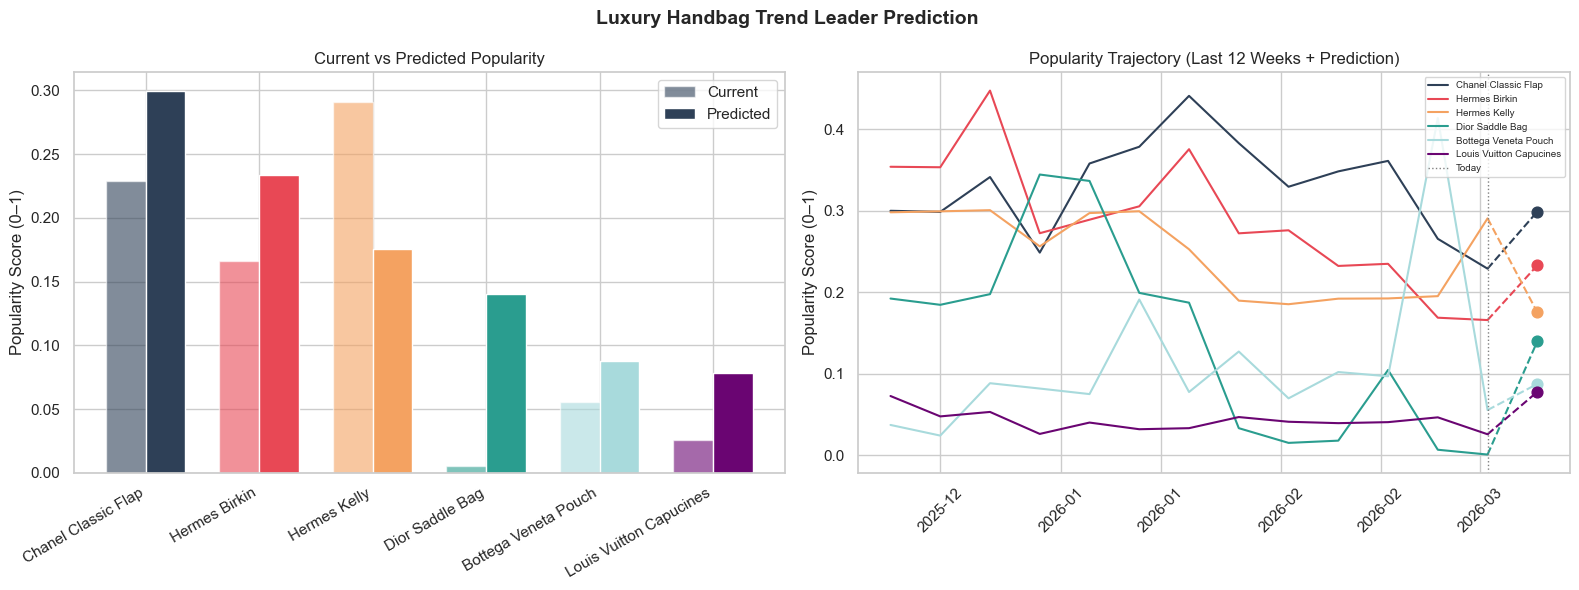

In [38]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Luxury Handbag Trend Leader Prediction", fontsize=14, fontweight='bold')

# Bar chart — current vs predicted
x     = np.arange(len(result))
width = 0.35

current_vals   = result['current_popularity'].clip(lower=0.005)
predicted_vals = result['predicted_popularity'].clip(lower=0.005)

bars1 = axes[0].bar(x - width/2, current_vals,  width,
                     label='Current',   color=[BAG_COLORS[b] for b in result['bag_query']], alpha=0.6)
bars2 = axes[0].bar(x + width/2, predicted_vals, width,
                     label='Predicted', color=[BAG_COLORS[b] for b in result['bag_query']], alpha=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(result['bag_query'], rotation=30, ha='right')
axes[0].set_ylabel("Popularity Score (0–1)")
axes[0].set_title("Current vs Predicted Popularity")
axes[0].legend()

# Line chart — popularity trajectory last 12 weeks + prediction 
axes[1].set_title("Popularity Trajectory (Last 12 Weeks + Prediction)")
last_12 = df_weekly[df_weekly['week'] >= df_weekly['week'].max() - pd.Timedelta(weeks=12)]
next_week = df_weekly['week'].max() + pd.Timedelta(weeks=1)

for bag, color in BAG_COLORS.items():
    data = last_12[last_12['bag_query'] == bag].sort_values('week')
    axes[1].plot(data['week'], data['popularity_score'], color=color, linewidth=1.5, label=bag)
    
    pred_val = result[result['bag_query'] == bag]['predicted_popularity'].values
    if len(pred_val) > 0:
        # Use last available week for this bag (not just latest week overall)
        bag_all = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
        if len(bag_all) > 0:
            last_known_week  = bag_all['week'].iloc[-1]
            last_known_score = bag_all['popularity_score'].iloc[-1]
            axes[1].plot([last_known_week, next_week], [last_known_score, pred_val[0]],
                         color=color, linewidth=1.5, linestyle='--')
            axes[1].scatter([next_week], [pred_val[0]], color=color, s=60, zorder=5)

axes[1].axvline(df_weekly['week'].max(), color='gray', linestyle=':', linewidth=1, label='Today')
axes[1].set_ylabel("Popularity Score (0–1)")
axes[1].legend(fontsize=7)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 5.2. Correlation Analysis

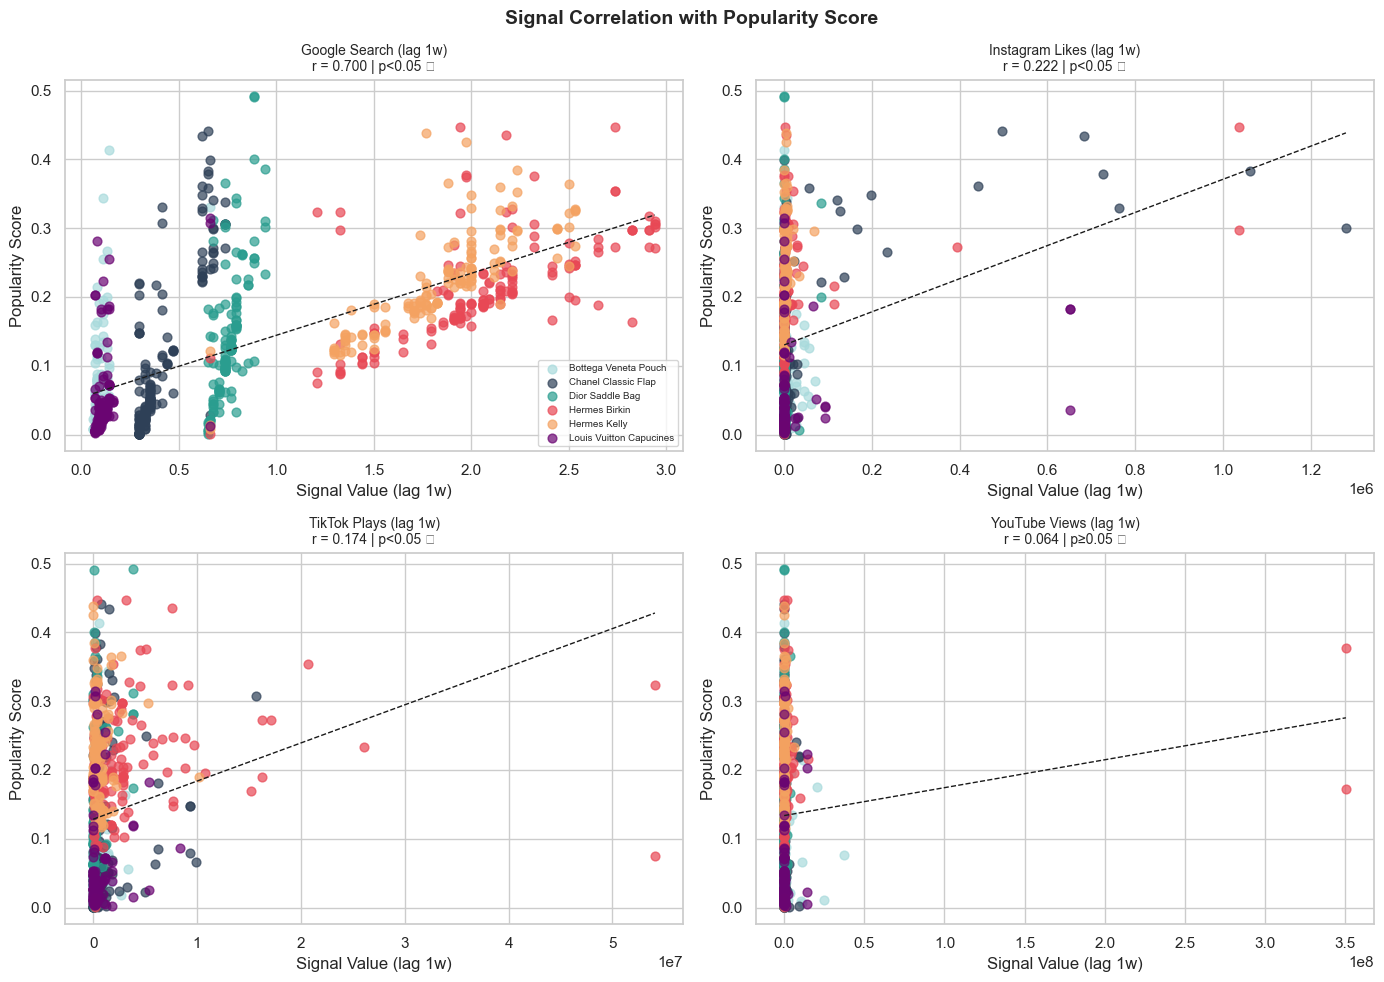

 CORRELATION SUMMARY 

                  Signal     r  p_value   n
  Google Search (lag 1w) 0.700   0.0000 858
Instagram Likes (lag 1w) 0.222   0.0000 858
   TikTok Plays (lag 1w) 0.174   0.0000 858
  YouTube Views (lag 1w) 0.064   0.0602 858


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Signal Correlation with Popularity Score", fontsize=14, fontweight='bold')

signals = {
    'Google Search (lag 1w)':    'search_index_lag1',
    'Instagram Likes (lag 1w)':  'ig_total_likes_lag1',
    'TikTok Plays (lag 1w)':     'tt_total_plays_lag1',
    'YouTube Views (lag 1w)':    'yt_total_views_lag1',
}

axes = axes.flatten()
corr_results = []

for i, (label, col) in enumerate(signals.items()):
    data = df_model_pop[[col, 'popularity_score']].dropna()
    r, p = stats.pearsonr(data[col], data['popularity_score'])
    corr_results.append({'Signal': label, 'r': round(r, 3), 'p_value': round(p, 4), 'n': len(data)})

    for bag in df_model_pop['bag_query'].unique():
        mask = df_model_pop['bag_query'] == bag
        axes[i].scatter(df_model_pop.loc[mask, col],
                        df_model_pop.loc[mask, 'popularity_score'],
                        color=BAG_COLORS[bag], label=bag, alpha=0.7, s=40)

    z = np.polyfit(data[col], data['popularity_score'], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 100)
    axes[i].plot(x_line, p_line(x_line), 'k--', linewidth=1)

    sig = "p<0.05 ✓" if p < 0.05 else "p≥0.05 ✗"
    axes[i].set_title(f"{label}\nr = {r:.3f} | {sig}", fontsize=10)
    axes[i].set_xlabel("Signal Value (lag 1w)")
    axes[i].set_ylabel("Popularity Score")
    if i == 0:
        axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

print(" CORRELATION SUMMARY \n")
corr_df = pd.DataFrame(corr_results).sort_values('r', ascending=False)
print(corr_df.to_string(index=False))

### 5.2.1. Actual vs. Predicted

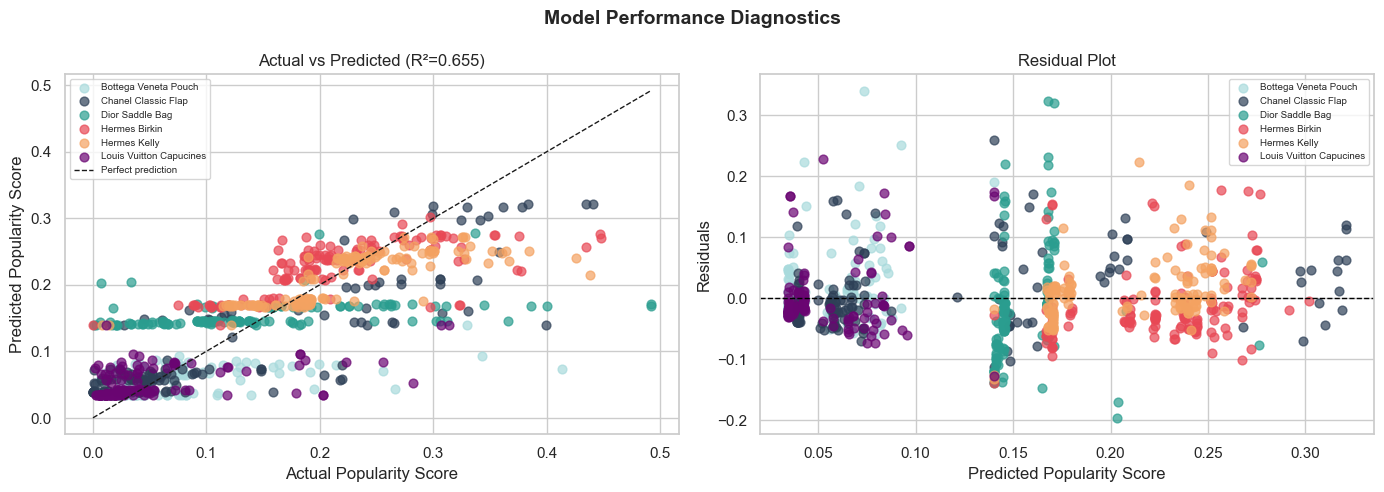

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance Diagnostics", fontsize=14, fontweight='bold')

# Actual vs Predicted 
y_pred_rf_all = rf.predict(X_scaled)

for i, bag in enumerate(df_model_pop['bag_query'].unique()):
    mask = df_model_pop['bag_query'] == bag
    axes[0].scatter(y[mask], y_pred_rf_all[mask], 
                    color=BAG_COLORS[bag], label=bag, alpha=0.7, s=40)

# Perfect prediction line
min_val = min(y.min(), y_pred_rf_all.min())
max_val = max(y.max(), y_pred_rf_all.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 
             'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel("Actual Popularity Score")
axes[0].set_ylabel("Predicted Popularity Score")
axes[0].set_title(f"Actual vs Predicted (R²={r2_score(y, y_pred_rf_all):.3f})")
axes[0].legend(fontsize=7)

#  Residuals 
residuals = y - y_pred_rf_all

for bag in df_model_pop['bag_query'].unique():
    mask = df_model_pop['bag_query'] == bag
    axes[1].scatter(y_pred_rf_all[mask], residuals[mask],
                    color=BAG_COLORS[bag], label=bag, alpha=0.7, s=40)

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel("Predicted Popularity Score")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 5.3. Per-Bag R²

In [41]:
print("=== Per-bag R² ===")
for bag in df_model_pop['bag_query'].unique():
    mask = df_model_pop['bag_query'] == bag
    if mask.sum() > 2:
        r2 = r2_score(y[mask], y_pred_rf_all[mask])
        print(f"  {bag}: R²={r2:.3f} (n={mask.sum()})")

=== Per-bag R² ===
  Bottega Veneta Pouch: R²=0.204 (n=142)
  Chanel Classic Flap: R²=0.729 (n=153)
  Dior Saddle Bag: R²=0.111 (n=134)
  Hermes Birkin: R²=0.412 (n=148)
  Hermes Kelly: R²=0.541 (n=143)
  Louis Vuitton Capucines: R²=0.252 (n=138)


## 5.4. Feature Importance

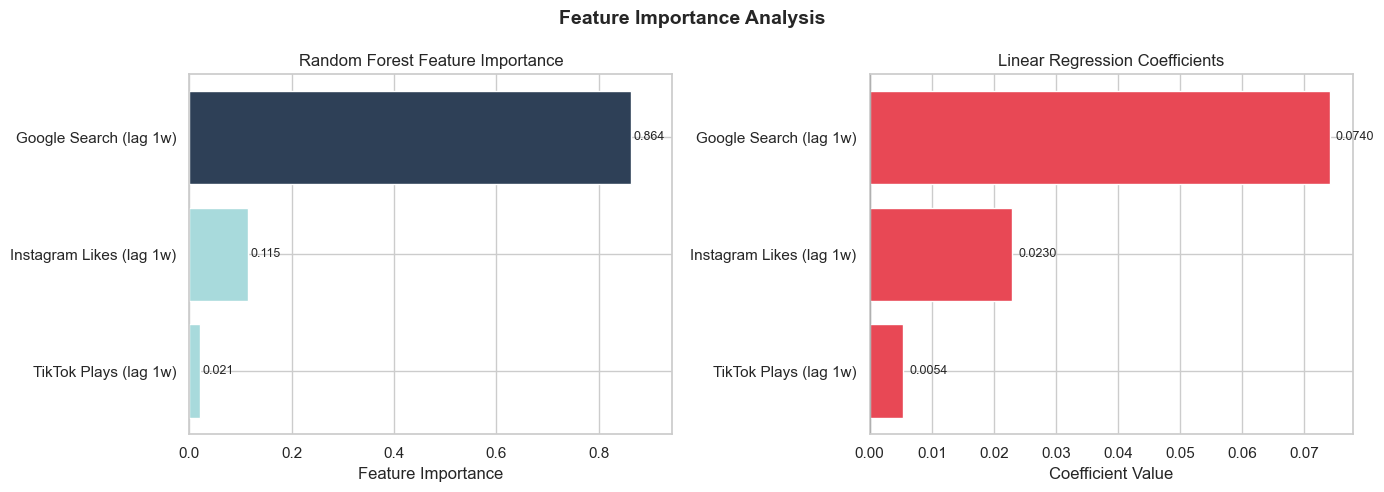

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance Analysis", fontsize=14, fontweight='bold')

#RF
imp_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)


label_map = {
    'search_index_lag1':     'Google Search (lag 1w)',
    'ig_total_likes_lag1':   'Instagram Likes (lag 1w)',
    'tt_total_plays_lag1':   'TikTok Plays (lag 1w)',
    'yt_total_views_lag1':   'YouTube Views (lag 1w)',
}
imp_df['label'] = imp_df['feature'].map(label_map)

colors = ['#2E4057' if i == len(imp_df)-1 else '#A8DADC' for i in range(len(imp_df))]
axes[0].barh(imp_df['label'], imp_df['importance'], color=colors)
axes[0].set_xlabel("Feature Importance")
axes[0].set_title("Random Forest Feature Importance")
for i, (val, label) in enumerate(zip(imp_df['importance'], imp_df['label'])):
    axes[0].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)
axes[0].set_xlim(0, imp_df['importance'].max() + 0.08)

#LR Coefficients
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=True)
coef_df['label'] = coef_df['feature'].map(label_map)

colors_lr = ['#E84855' if c > 0 else '#2E4057' for c in coef_df['coefficient']]
axes[1].barh(coef_df['label'], coef_df['coefficient'], color=colors_lr)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Coefficient Value")
axes[1].set_title("Linear Regression Coefficients")
for i, val in enumerate(coef_df['coefficient']):
    axes[1].text(val + 0.001 if val >= 0 else val - 0.001, i,
                 f'{val:.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

In [43]:
print(" FEATURE IMPORTANCE SUMMARY \n")
imp_df_print = imp_df[['label', 'importance']].sort_values('importance', ascending=False)
imp_df_print['importance_%'] = (imp_df_print['importance'] * 100).round(1)
print(imp_df_print.to_string(index=False))

 FEATURE IMPORTANCE SUMMARY 

                   label  importance  importance_%
  Google Search (lag 1w)    0.863724          86.4
Instagram Likes (lag 1w)    0.115461          11.5
   TikTok Plays (lag 1w)    0.020815           2.1


## 5.5. Per-bag popularity trajectory

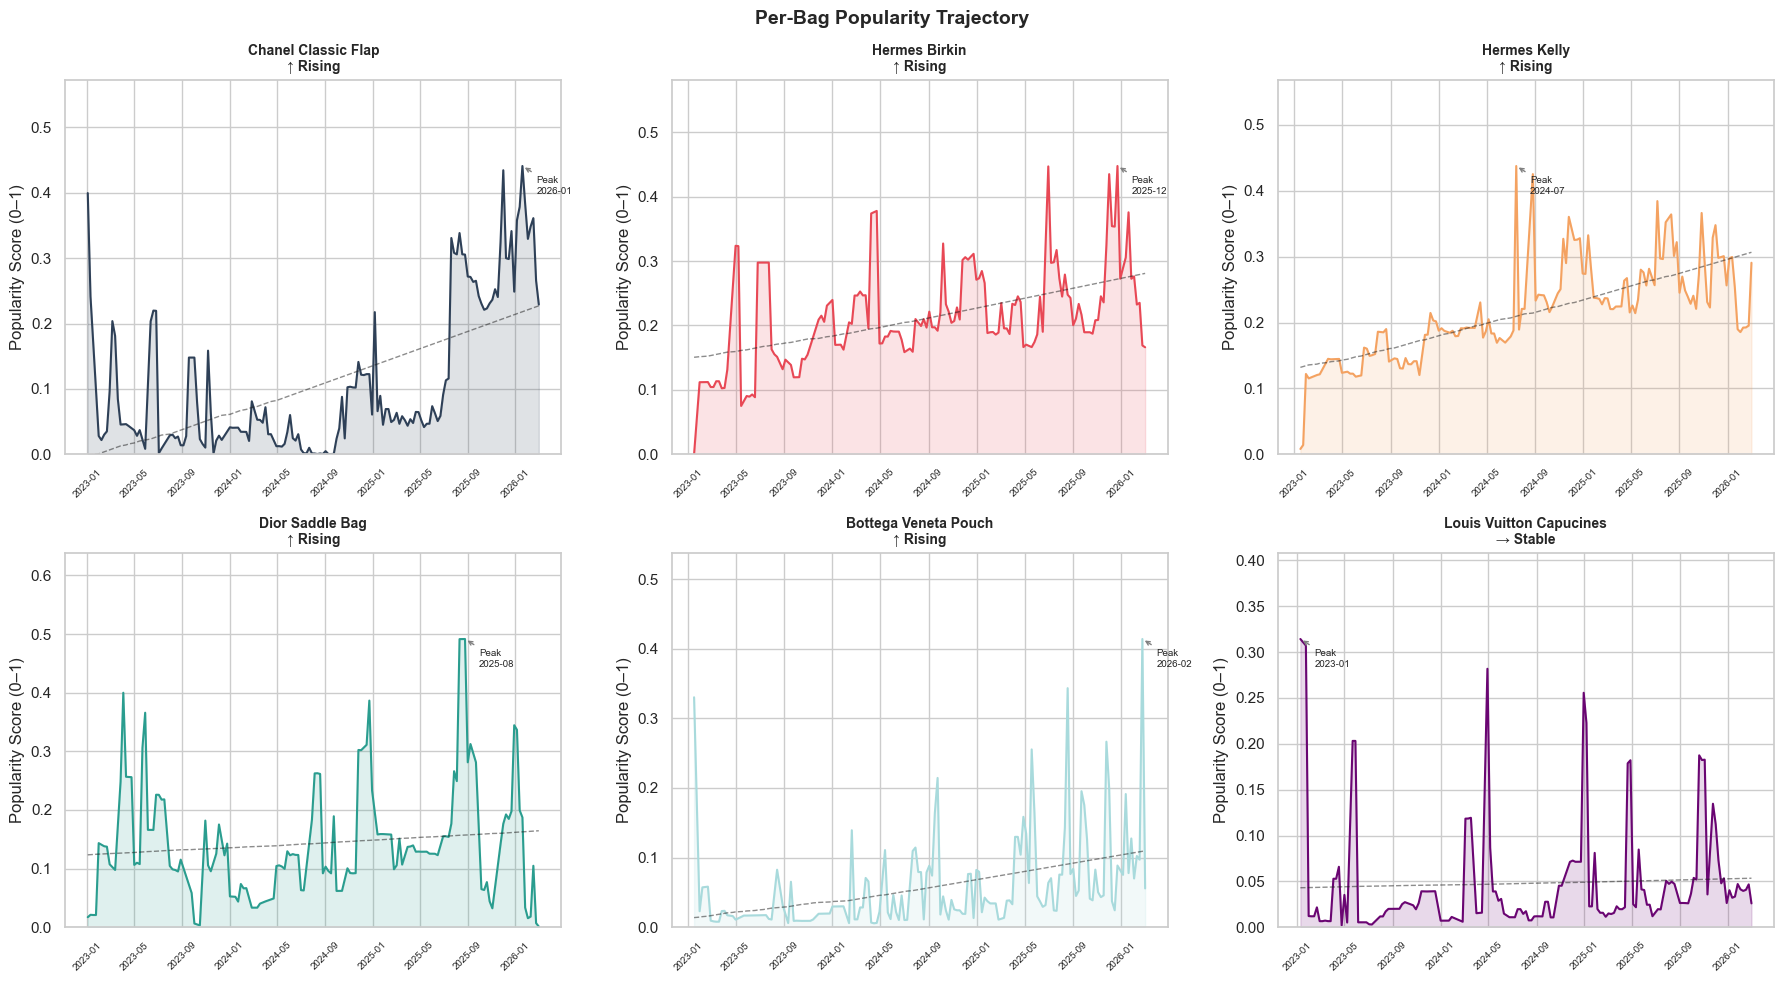

 TREND DIRECTION SUMMARY 

  Chanel Classic Flap: slope=0.00151 | momentum=Accelerating | recent avg=0.301 | overall avg=0.112
  Hermes Birkin: slope=0.00089 | momentum=Stable | recent avg=0.201 | overall avg=0.216
  Hermes Kelly: slope=0.00123 | momentum=Stable | recent avg=0.218 | overall avg=0.219
  Dior Saddle Bag: slope=0.00031 | momentum=Decelerating | recent avg=0.033 | overall avg=0.144
  Bottega Veneta Pouch: slope=0.00068 | momentum=Accelerating | recent avg=0.167 | overall avg=0.062
  Louis Vuitton Capucines: slope=0.00008 | momentum=Decelerating | recent avg=0.038 | overall avg=0.048


In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Per-Bag Popularity Trajectory", fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (bag, color) in enumerate(BAG_COLORS.items()):
    data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
    
    ax = axes[i]
    ax.plot(data['week'], data['popularity_score'], color=color, linewidth=1.5)
    ax.fill_between(data['week'], data['popularity_score'], alpha=0.15, color=color)
    
    if len(data) > 2:
        x_num = np.arange(len(data))
        z = np.polyfit(x_num, data['popularity_score'], 1)
        p_line = np.poly1d(z)
        ax.plot(data['week'], p_line(x_num), 'k--', linewidth=1, alpha=0.5, label='Trend')
    
    peak_idx  = data['popularity_score'].idxmax()
    peak_week = data.loc[peak_idx, 'week']
    peak_val  = data.loc[peak_idx, 'popularity_score']
    ax.annotate(f'Peak\n{peak_week.strftime("%Y-%m")}',
                xy=(peak_week, peak_val),
                xytext=(10, -20), textcoords='offset points',
                fontsize=7, arrowprops=dict(arrowstyle='->', color='gray'))
    
    slope = np.polyfit(np.arange(len(data)), data['popularity_score'], 1)[0]
    direction = '↑ Rising' if slope > 0.0001 else ('↓ Falling' if slope < -0.0001 else '→ Stable')
    ax.set_title(f"{bag}\n{direction}", fontsize=10, fontweight='bold')
    ax.set_ylabel("Popularity Score (0–1)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)
    ax.set_ylim(0, data['popularity_score'].max() * 1.3)

plt.tight_layout()
plt.show()

print(" TREND DIRECTION SUMMARY \n")
for bag in BAG_COLORS.keys():
    data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
    slope = np.polyfit(np.arange(len(data)), data['popularity_score'], 1)[0]
    recent = data.tail(4)['popularity_score'].mean()
    overall = data['popularity_score'].mean()
    momentum = 'Accelerating' if recent > overall * 1.1 else ('Decelerating' if recent < overall * 0.9 else 'Stable')
    print(f"  {bag}: slope={slope:.5f} | momentum={momentum} | recent avg={recent:.3f} | overall avg={overall:.3f}")

# 6. Model Validation

## 6.1. Residual plots

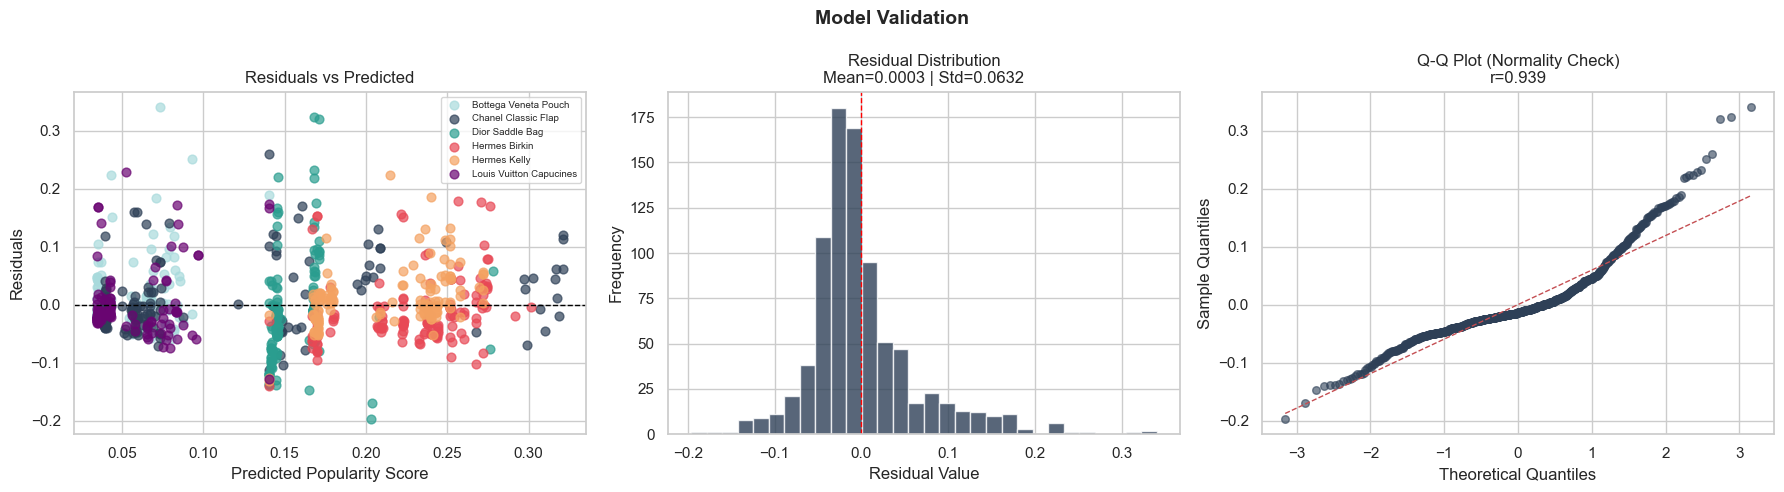

In [45]:

y_pred = rf.predict(X_scaled)
residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Validation", fontsize=14, fontweight='bold')

# Residuals vs Predicted
for bag in df_model_pop['bag_query'].unique():
    mask = df_model_pop['bag_query'] == bag
    axes[0].scatter(y_pred[mask], residuals[mask],
                    color=BAG_COLORS[bag], label=bag, alpha=0.7, s=40)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel("Predicted Popularity Score")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")
axes[0].legend(fontsize=7)

# Residual distribution
axes[1].hist(residuals, bins=30, color='#2E4057', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Residual Distribution\nMean={residuals.mean():.4f} | Std={residuals.std():.4f}")

# Q-Q plot (normality check)
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
axes[2].scatter(osm, osr, color='#2E4057', alpha=0.6, s=30)
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1)
axes[2].set_xlabel("Theoretical Quantiles")
axes[2].set_ylabel("Sample Quantiles")
axes[2].set_title(f"Q-Q Plot (Normality Check)\nr={r:.3f}")

plt.tight_layout()
plt.show()

## 6.2. Per-Bag Model Performance

In [46]:
print("=== Per-Bag Model Performance ===")
per_bag_results = []
for bag in df_model_pop['bag_query'].unique():
    mask = df_model_pop['bag_query'] == bag
    if mask.sum() > 2:
        r2   = r2_score(y[mask], y_pred[mask])
        rmse = np.sqrt(mean_squared_error(y[mask], y_pred[mask]))
        per_bag_results.append({'Bag': bag, 'n': mask.sum(), 'R²': round(r2, 3), 'RMSE': round(rmse, 4)})

per_bag_df = pd.DataFrame(per_bag_results).sort_values('R²', ascending=False)
print(per_bag_df.to_string(index=False))

=== Per-Bag Model Performance ===
                    Bag   n    R²   RMSE
    Chanel Classic Flap 153 0.729 0.0603
           Hermes Kelly 143 0.541 0.0487
          Hermes Birkin 148 0.412 0.0576
Louis Vuitton Capucines 138 0.252 0.0535
   Bottega Veneta Pouch 142 0.204 0.0616
        Dior Saddle Bag 134 0.111 0.0908


## 6.3. Statistical Significance Features

In [47]:
print("\n Feature Significance (Pearson r vs popularity_score) \n")
for col in feature_cols:
    data = df_model_pop[[col, 'popularity_score']].dropna()
    r, p = stats.pearsonr(data[col], data['popularity_score'])
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"  {col}: r={r:.3f} | p={p:.4f} | {sig}")


 Feature Significance (Pearson r vs popularity_score) 

  search_index_lag1: r=0.700 | p=0.0000 | ✓ significant
  tt_total_plays_lag1: r=0.174 | p=0.0000 | ✓ significant
  ig_total_likes_lag1: r=0.222 | p=0.0000 | ✓ significant


## 6.4. Spearman correlation

SPEARMAN RANK CORRELATION — ROBUSTNESS CHECK

              Feature  Pearson r  Pearson p Pearson sig  Spearman r  Spearman p Spearman sig Consistent
  Search Index (Lag1)      0.700        0.0           ✓       0.756         0.0            ✓          ✓
Tt Total Plays (Lag1)      0.174        0.0           ✓       0.314         0.0            ✓          ✓
Ig Total Likes (Lag1)      0.222        0.0           ✓       0.402         0.0            ✓          ✓

INTERPRETATION 

  Search Index (Lag1): Both methods agree — result is robust
  Tt Total Plays (Lag1): Both methods agree — result is robust
  Ig Total Likes (Lag1): Both methods agree — result is robust


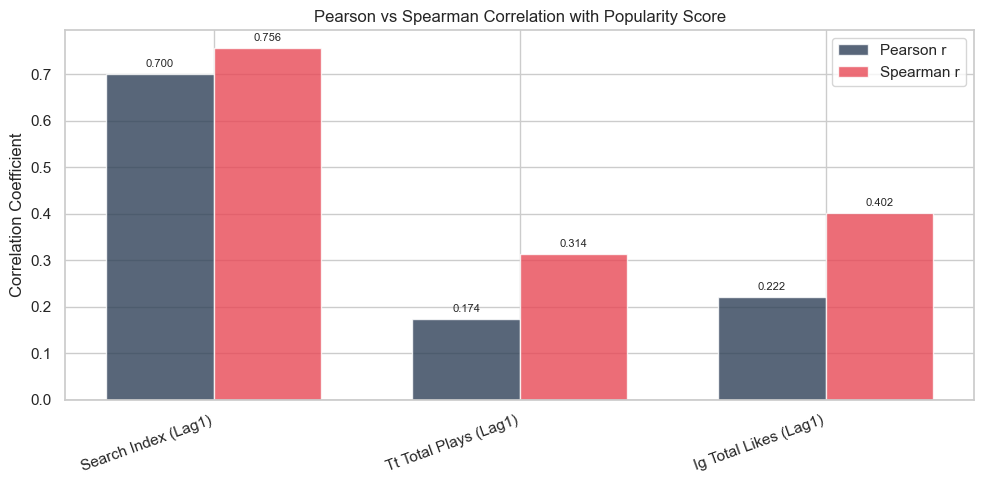

In [48]:
from scipy import stats
print("SPEARMAN RANK CORRELATION — ROBUSTNESS CHECK\n")



results = []
for col in feature_cols:
    data = df_model_pop[[col, 'popularity_score']].dropna()

    pearson_r,  pearson_p  = stats.pearsonr(data[col],  data['popularity_score'])
    spearman_r, spearman_p = stats.spearmanr(data[col], data['popularity_score'])

    results.append({
        'Feature':      col.replace('_lag1', ' (lag1)').replace('_', ' ').title(),
        'Pearson r':    round(pearson_r,  3),
        'Pearson p':    round(pearson_p,  4),
        'Pearson sig':  '✓' if pearson_p  < 0.05 else '✗',
        'Spearman r':   round(spearman_r, 3),
        'Spearman p':   round(spearman_p, 4),
        'Spearman sig': '✓' if spearman_p < 0.05 else '✗',
        'Consistent':   '✓' if (pearson_p < 0.05) == (spearman_p < 0.05) else '✗ DIFFERS',
    })

corr_comparison = pd.DataFrame(results)
print(corr_comparison.to_string(index=False))

print("\nINTERPRETATION \n")
for _, row in corr_comparison.iterrows():
    if row['Consistent'] == '✓':
        print(f"  {row['Feature']}: Both methods agree — result is robust")
    else:
        print(f"  {row['Feature']}: Methods DISAGREE — interpret with caution")

# Pearson vs. Spearman bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(corr_comparison))
width   = 0.35

bars1 = ax.bar(x - width/2, corr_comparison['Pearson r'],
               width, label='Pearson r', color='#2E4057', alpha=0.8)
bars2 = ax.bar(x + width/2, corr_comparison['Spearman r'],
               width, label='Spearman r', color='#E84855', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(corr_comparison['Feature'], rotation=20, ha='right')
ax.set_ylabel("Correlation Coefficient")
ax.set_title("Pearson vs Spearman Correlation with Popularity Score")
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 6.5. Time Series Stationary Check

In [49]:

print("ADF TEST")

variables = {
    'search_index':     'Google Search Index',
    'tt_total_plays':   'TikTok Total Plays',
    'ig_total_likes':   'Instagram Likes',
    'yt_total_views':   'YouTube Views',
}

adf_results = []

for bag in BAG_COLORS.keys():
    bag_data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
    
    for col, label in variables.items():
        series = bag_data[col].dropna()
        
        if len(series) < 10:
            continue
            
        adf_stat, p_value, lags, nobs, crit_vals, _ = adfuller(series, autolag='AIC')
        
        adf_results.append({
            'Bag':        bag,
            'Variable':   label,
            'ADF Stat':   round(adf_stat, 3),
            'p-value':    round(p_value, 4),
            'Lags':       lags,
            'Stationary': '✓' if p_value < 0.05 else '✗',
        })

adf_df = pd.DataFrame(adf_results)

for var_label in variables.values():
    print(f"\n {var_label} \n")
    subset = adf_df[adf_df['Variable'] == var_label][['Bag', 'ADF Stat', 'p-value', 'Stationary']]
    print(subset.to_string(index=False))

ADF TEST

 Google Search Index 

                    Bag  ADF Stat  p-value Stationary
    Chanel Classic Flap    -1.998   0.2875          ✗
          Hermes Birkin    -4.119   0.0009          ✓
           Hermes Kelly    -2.154   0.2232          ✗
        Dior Saddle Bag    -3.834   0.0026          ✓
   Bottega Veneta Pouch   -28.025   0.0000          ✓
Louis Vuitton Capucines    -2.973   0.0375          ✓

 TikTok Total Plays 

                    Bag  ADF Stat  p-value Stationary
    Chanel Classic Flap    -8.927   0.0000          ✓
          Hermes Birkin    -7.650   0.0000          ✓
           Hermes Kelly   -11.120   0.0000          ✓
        Dior Saddle Bag    -3.770   0.0032          ✓
   Bottega Veneta Pouch    -9.069   0.0000          ✓
Louis Vuitton Capucines    -4.872   0.0000          ✓

 Instagram Likes 

                    Bag  ADF Stat  p-value Stationary
    Chanel Classic Flap    -1.961   0.3040          ✗
          Hermes Birkin    -5.823   0.0000          ✓
      

In [50]:
print("\nSUMMARY \n")
total      = len(adf_df)
stationary = (adf_df['Stationary'] == '✓').sum()
print(f"Stationary series:     {stationary}/{total} ({stationary/total*100:.0f}%)")
print(f"Non-stationary series: {total - stationary}/{total} ({(total-stationary)/total*100:.0f}%)")


non_stationary = adf_df[adf_df['Stationary'] == '✗'][['Bag', 'Variable']].values
if len(non_stationary) > 0:
    print(f"\nNon-stationary series detected — applying first differencing:")
    for bag, var in non_stationary:
        col = [k for k, v in variables.items() if v == var][0]
        bag_data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
        series_diff = bag_data[col].diff().dropna()
        if len(series_diff) >= 10:
            adf_stat, p_value, _, _, _, _ = adfuller(series_diff, autolag='AIC')
            status = '✓ stationary after differencing' if p_value < 0.05 else '✗ still non-stationary'
            print(f"  {bag} — {var}: p={p_value:.4f} {status}")


SUMMARY 

Stationary series:     20/24 (83%)
Non-stationary series: 4/24 (17%)

Non-stationary series detected — applying first differencing:
  Chanel Classic Flap — Google Search Index: p=0.0000 ✓ stationary after differencing
  Chanel Classic Flap — Instagram Likes: p=0.0046 ✓ stationary after differencing
  Hermes Kelly — Google Search Index: p=0.0000 ✓ stationary after differencing
  Dior Saddle Bag — Instagram Likes: p=0.0000 ✓ stationary after differencing


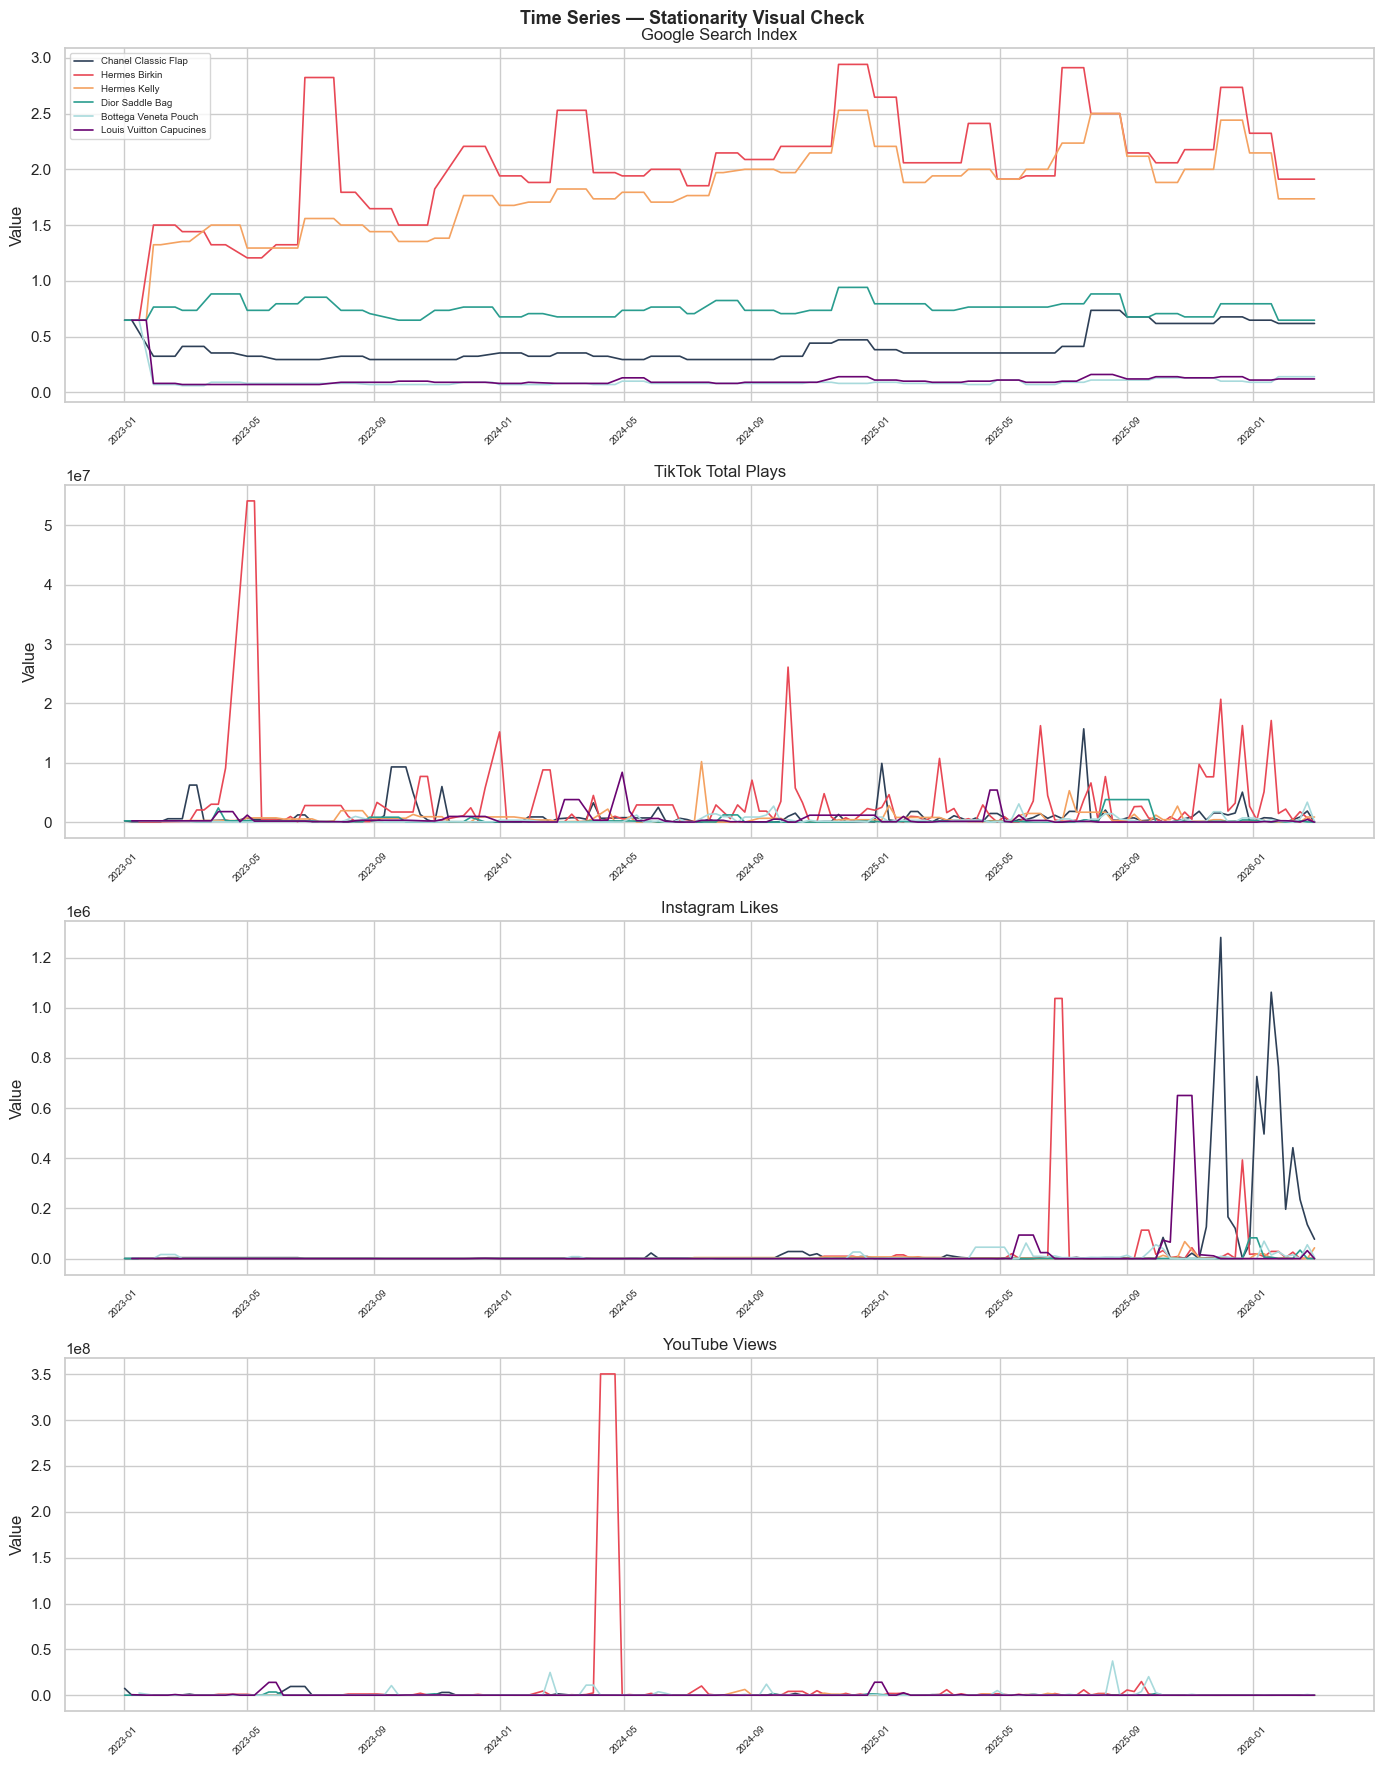

In [51]:
fig, axes = plt.subplots(len(variables), 1, figsize=(14, 18))
fig.suptitle("Time Series — Stationarity Visual Check", fontsize=13, fontweight='bold')

for i, (col, label) in enumerate(variables.items()):
    for bag, color in BAG_COLORS.items():
        data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
        axes[i].plot(data['week'], data[col], color=color, linewidth=1.2, label=bag)
    axes[i].set_title(label)
    axes[i].set_ylabel("Value")
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[i].get_xticklabels(), rotation=45, fontsize=7)
    if i == 0:
        axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 6.6. Temporal Train/Test Split

TEMPORAL TRAIN/TEST SPLIT VALIDATION

Train: 662 rows | 2023-01-02 → 2025-07-07
Test:  196 rows  | 2025-07-14 → 2026-03-02
Split week: 2025-07-14

Linear Regression — Temporal Split 

Train R²: 0.607
Test  R²: 0.114
Test RMSE: 0.1119

Random Forest — Temporal Split 

Train R²: 0.686
Test  R²: 0.103
Test RMSE: 0.1126

VALIDATION COMPARISON SUMMARY 

Method                            LR R²    RF R²
------------------------------------------------
In-sample                         0.538    0.655
5-Fold CV (random)                0.514    0.609
Temporal split (test)             0.114    0.103


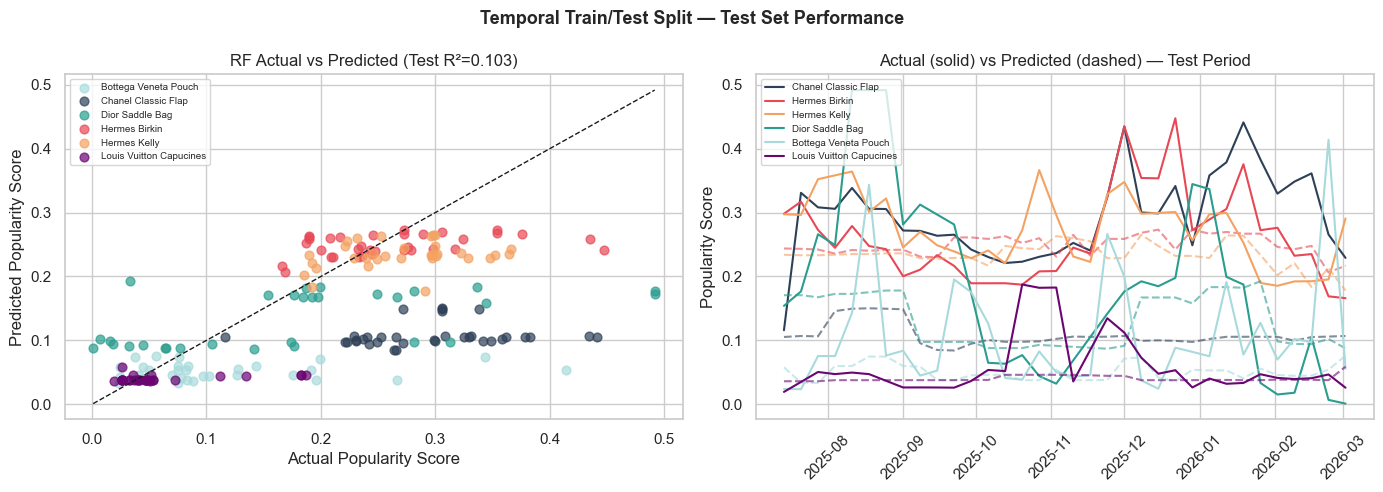

In [52]:

print("TEMPORAL TRAIN/TEST SPLIT VALIDATION\n")


sorted_weeks = sorted(df_model_pop['week'].unique())
split_idx    = int(len(sorted_weeks) * 0.8)
split_week   = sorted_weeks[split_idx]

train = df_model_pop[df_model_pop['week'] <  split_week].copy()
test  = df_model_pop[df_model_pop['week'] >= split_week].copy()

print(f"Train: {len(train)} rows | {train['week'].min().strftime('%Y-%m-%d')} → {train['week'].max().strftime('%Y-%m-%d')}")
print(f"Test:  {len(test)} rows  | {test['week'].min().strftime('%Y-%m-%d')} → {test['week'].max().strftime('%Y-%m-%d')}")
print(f"Split week: {split_week.strftime('%Y-%m-%d')}")

X_train = train[feature_cols]
y_train = train['popularity_score']
X_test  = test[feature_cols]
y_test  = test['popularity_score']

scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train)
X_test_scaled  = scaler_temp.transform(X_test)

# LR
lr_temp = LinearRegression()
lr_temp.fit(X_train_scaled, y_train)
lr_test_pred = lr_temp.predict(X_test_scaled)

print("\nLinear Regression — Temporal Split \n")
print(f"Train R²: {r2_score(y_train, lr_temp.predict(X_train_scaled)):.3f}")
print(f"Test  R²: {r2_score(y_test,  lr_test_pred):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")

# RF
rf_temp = RandomForestRegressor(n_estimators=100, max_depth=3,
                                min_samples_leaf=5, random_state=42)
rf_temp.fit(X_train_scaled, y_train)
rf_test_pred = rf_temp.predict(X_test_scaled)

print("\nRandom Forest — Temporal Split \n")
print(f"Train R²: {r2_score(y_train, rf_temp.predict(X_train_scaled)):.3f}")
print(f"Test  R²: {r2_score(y_test,  rf_test_pred):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, rf_test_pred)):.4f}")


print("\nVALIDATION COMPARISON SUMMARY \n")
print(f"{'Method':<30} {'LR R²':>8} {'RF R²':>8}")
print("-" * 48)
print(f"{'In-sample':<30} {r2_score(y, y_pred_lr):>8.3f} {r2_score(y, y_pred_rf):>8.3f}")
print(f"{'5-Fold CV (random)':<30} {lr_cv.mean():>8.3f} {rf_cv.mean():>8.3f}")
print(f"{'Temporal split (test)':<30} {r2_score(y_test, lr_test_pred):>8.3f} {r2_score(y_test, rf_test_pred):>8.3f}")

# Plot: actual vs predicted on test set 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Temporal Train/Test Split — Test Set Performance", fontsize=13, fontweight='bold')

for bag in test['bag_query'].unique():
    mask = test['bag_query'] == bag
    axes[0].scatter(y_test[mask], rf_test_pred[mask],
                    color=BAG_COLORS[bag], label=bag, alpha=0.7, s=40)

min_val = min(y_test.min(), rf_test_pred.min())
max_val = max(y_test.max(), rf_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)
axes[0].set_xlabel("Actual Popularity Score")
axes[0].set_ylabel("Predicted Popularity Score")
axes[0].set_title(f"RF Actual vs Predicted (Test R²={r2_score(y_test, rf_test_pred):.3f})")
axes[0].legend(fontsize=7)

# Timeline: actual vs predicted over time on test set
test = test.copy()
test['rf_predicted'] = rf_test_pred
for bag, color in BAG_COLORS.items():
    bag_test = test[test['bag_query'] == bag].sort_values('week')
    if len(bag_test) == 0:
        continue
    axes[1].plot(bag_test['week'], bag_test['popularity_score'],
                 color=color, linewidth=1.5, label=bag)
    axes[1].plot(bag_test['week'], bag_test['rf_predicted'],
                 color=color, linewidth=1.5, linestyle='--', alpha=0.6)

axes[1].set_title("Actual (solid) vs Predicted (dashed) — Test Period")
axes[1].set_ylabel("Popularity Score")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].legend(fontsize=7)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [53]:
recent_weeks  = sorted(df_model_pop['week'].unique())
recent_split  = recent_weeks[-4]  # last 4 weeks as test

train_recent = df_model_pop[df_model_pop['week'] <  recent_split]
test_recent  = df_model_pop[df_model_pop['week'] >= recent_split]

print(f"Recent train: {len(train_recent)} rows")
print(f"Recent test:  {len(test_recent)} rows")

Recent train: 834 rows
Recent test:  24 rows


## 6.7. Shapiro-Wilk

In [54]:
print("\nResidual Normality (Shapiro-Wilk) \n")
stat, p = stats.shapiro(residuals)
print(f"  W={stat:.4f} | p={p:.4f}")
print(f"  {'✓ Residuals are normally distributed (p>0.05)' if p > 0.05 else '✗ Residuals deviate from normality (p<0.05)'}")



Residual Normality (Shapiro-Wilk) 

  W=0.8837 | p=0.0000
  ✗ Residuals deviate from normality (p<0.05)


# 7. Summary

## 7.1. Summary Table

In [55]:
signal_labels = {
    'search_index_lag1':   'Google Search',
    'tt_total_plays_lag1': 'TikTok',
    'ig_total_likes_lag1': 'Instagram',
}

def get_key_driver(bag):
    row = df_weekly[df_weekly['bag_query'] == bag].sort_values('week').iloc[-1]
    signals = {
        'Google Search': row['search_index_norm'],
        'TikTok':        row['tt_total_plays_norm'],
        'Instagram':     row['ig_total_likes_norm'],
    }
    return max(signals, key=signals.get)

result['key_driver'] = result['bag_query'].apply(get_key_driver)
result['rank_change'] = result['predicted_popularity'].rank(ascending=False).astype(int)


print("LUXURY HANDBAG TREND LEADER REPORT — Week of 2026-03-09\n")

print(f"{'Rank':<5} {'Bag':<25} {'Current':>10} {'Predicted':>10} {'Trend':>12} {'Key Driver':>15}")
print("-" * 80)
for _, row in result.iterrows():
    print(f"{_:<5} {row['bag_query']:<25} {row['current_popularity']:>10.3f} "
          f"{row['predicted_popularity']:>10.3f} {row['trend_direction']:>12} "
          f"{row['key_driver']:>15}")

print(f"\nModel: Random Forest | R²=0.617 (cross-validated) | Features: Google Search, TikTok, Instagram (all lag 1 week)")

LUXURY HANDBAG TREND LEADER REPORT — Week of 2026-03-09

Rank  Bag                          Current  Predicted        Trend      Key Driver
--------------------------------------------------------------------------------
1     Chanel Classic Flap            0.229      0.299    ↓ Falling   Google Search
2     Hermes Birkin                  0.166      0.233    ↓ Falling   Google Search
3     Hermes Kelly                   0.291      0.176     ↑ Rising       Instagram
4     Dior Saddle Bag                0.001      0.140    ↓ Falling       Instagram
5     Bottega Veneta Pouch           0.056      0.088     ↑ Rising   Google Search
6     Louis Vuitton Capucines        0.026      0.078    ↓ Falling   Google Search

Model: Random Forest | R²=0.617 (cross-validated) | Features: Google Search, TikTok, Instagram (all lag 1 week)


## 7.2. Data Limitations

In [56]:

print("DATA LIMITATIONS SUMMARY\n")


# eBay 
total_weeks  = df_weekly['week'].nunique()
ebay_covered = df_weekly.groupby('bag_query')['avg_resale_price'].apply(
    lambda x: x.notna().sum()
)
ebay_missing = df_weekly.groupby('bag_query')['avg_resale_price'].apply(
    lambda x: x.isna().sum()
)

print("\n1. EBAY PRICE COVERAGE\n")
ebay_cov_df = pd.DataFrame({
    'Weeks with data':    ebay_covered,
    'Weeks missing':      ebay_missing,
    'Coverage %':         (ebay_covered / total_weeks * 100).round(1),
})
print(ebay_cov_df.to_string())

# Social Media
print("\n2. SOCIAL MEDIA COVERAGE\n")
social_cols = {
    'yt_total_views':  'YouTube',
    'tt_total_plays':  'TikTok',
    'ig_total_likes':  'Instagram',
    'search_index':    'Google Trends',
}

for col, name in social_cols.items():
    covered = df_weekly[col].notna().sum()
    missing = df_weekly[col].isna().sum()
    pct     = covered / len(df_weekly) * 100
    print(f"  {name:<15}: {covered} weeks with data | {missing} missing | {pct:.1f}% coverage")

# Per-bag SM coverage
print("\n3. PER-BAG SOCIAL COVERAGE\n")
for col, name in social_cols.items():
    print(f"\n  {name}:")
    cov = df_weekly.groupby('bag_query')[col].apply(
        lambda x: f"{x.notna().sum()}/{len(x)} ({x.notna().sum()/len(x)*100:.0f}%)"
    )
    for bag, val in cov.items():
        print(f"    {bag}: {val}")

print("\n4. IMPUTATION APPLIED\n")
print("  Forward fill:  applied within each bag for all feature columns")
print("  Median fill:   applied for remaining nulls after forward fill")
fill_cols = ['search_index', 'yt_total_views', 'tt_total_plays', 'ig_total_likes']
for col in fill_cols:
    original_missing = df_weekly[col].isna().sum()
    print(f"  {col}: {original_missing} values imputed")

print("\n5. DATASET SIZE SUMMARY")
print(f"  Total weekly observations:        {len(df_weekly)}")
print(f"  Observations with price data:     {df_weekly['avg_resale_price'].notna().sum()} ({df_weekly['avg_resale_price'].notna().sum()/len(df_weekly)*100:.1f}%)")
print(f"  Observations used in model:       {len(df_model_pop)}")
print(f"  eBay date range:                  {ebay_filtered['sold_date'].min().strftime('%Y-%m-%d')} → {ebay_filtered['sold_date'].max().strftime('%Y-%m-%d')}")
print(f"  Social media date range:          2023-01-01 → {df_weekly['week'].max().strftime('%Y-%m-%d')}")
print(f"  Gap:                              eBay covers only {(ebay_covered.mean()/total_weeks*100):.0f}% of the social media time window")

DATA LIMITATIONS SUMMARY


1. EBAY PRICE COVERAGE

                         Weeks with data  Weeks missing  Coverage %
bag_query                                                          
Bottega Veneta Pouch                  10            132         6.0
Chanel Classic Flap                   14            139         8.4
Dior Saddle Bag                       15            119         9.0
Hermes Birkin                         14            134         8.4
Hermes Kelly                          14            129         8.4
Louis Vuitton Capucines               13            125         7.8

2. SOCIAL MEDIA COVERAGE

  YouTube        : 858 weeks with data | 0 missing | 100.0% coverage
  TikTok         : 858 weeks with data | 0 missing | 100.0% coverage
  Instagram      : 858 weeks with data | 0 missing | 100.0% coverage
  Google Trends  : 858 weeks with data | 0 missing | 100.0% coverage

3. PER-BAG SOCIAL COVERAGE


  YouTube:
    Bottega Veneta Pouch: 142/142 (100%)
    Chanel Classic F

## 7.3. Google Search on a Scale from 0-100 

For Report/Defense specifically

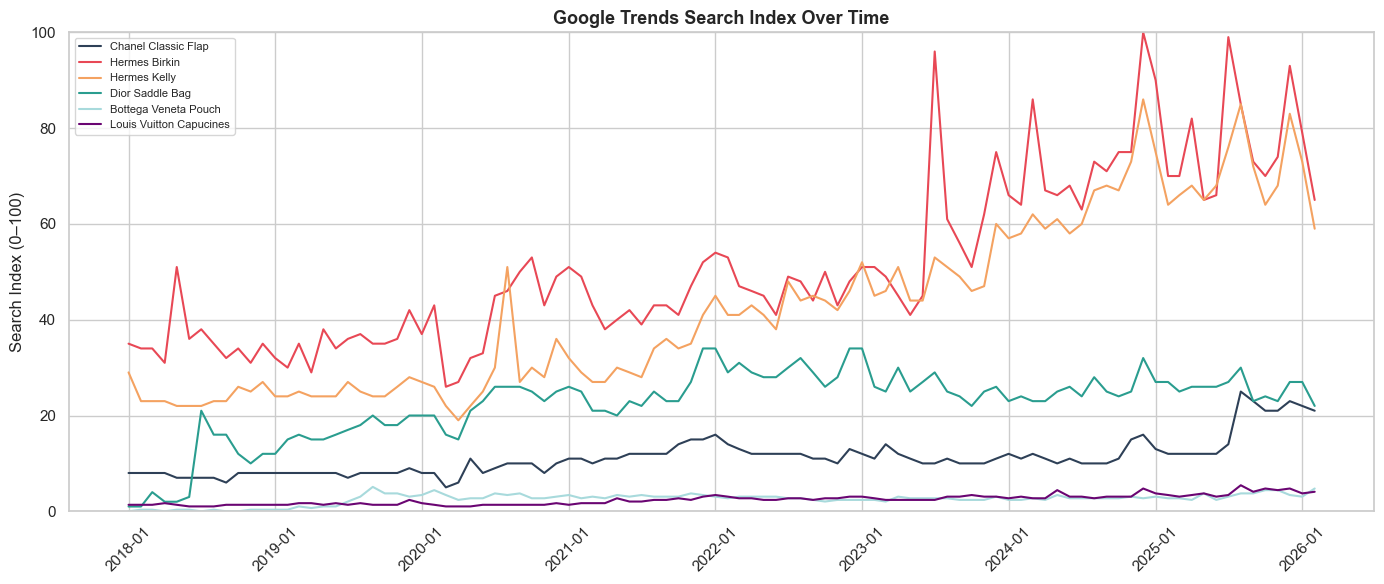

In [57]:
google_plot = google.copy()
google_plot['search_index_scaled'] = google_plot['search_index'] * 34

fig, ax = plt.subplots(figsize=(14, 6))
for bag, color in BAG_COLORS.items():
    data = google_plot[google_plot['bag_query'] == bag]
    ax.plot(data['month'], data['search_index_scaled'], label=bag, color=color, linewidth=1.5)

ax.set_title("Google Trends Search Index Over Time", fontsize=13, fontweight='bold')
ax.set_ylabel("Search Index (0–100)")
ax.set_xlabel("")
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7.4. ADF Stationary Summary

In [58]:
print(" ADF STATIONARITY RESULTS SUMMARY \n")
for bag in BAG_COLORS.keys():
    bag_data = df_weekly[df_weekly['bag_query'] == bag].sort_values('week')
    for col, label in variables.items():
        series = bag_data[col].dropna()
        if len(series) >= 10:
            adf_stat, p_value, _, _, _, _ = adfuller(series, autolag='AIC')
            status = '✓ stationary' if p_value < 0.05 else '✗ non-stationary'
            print(f"{bag} | {label}: p={p_value:.4f} {status}")

 ADF STATIONARITY RESULTS SUMMARY 

Chanel Classic Flap | Google Search Index: p=0.2875 ✗ non-stationary
Chanel Classic Flap | TikTok Total Plays: p=0.0000 ✓ stationary
Chanel Classic Flap | Instagram Likes: p=0.3040 ✗ non-stationary
Chanel Classic Flap | YouTube Views: p=0.0001 ✓ stationary
Hermes Birkin | Google Search Index: p=0.0009 ✓ stationary
Hermes Birkin | TikTok Total Plays: p=0.0000 ✓ stationary
Hermes Birkin | Instagram Likes: p=0.0000 ✓ stationary
Hermes Birkin | YouTube Views: p=0.0000 ✓ stationary
Hermes Kelly | Google Search Index: p=0.2232 ✗ non-stationary
Hermes Kelly | TikTok Total Plays: p=0.0000 ✓ stationary
Hermes Kelly | Instagram Likes: p=0.0003 ✓ stationary
Hermes Kelly | YouTube Views: p=0.0000 ✓ stationary
Dior Saddle Bag | Google Search Index: p=0.0026 ✓ stationary
Dior Saddle Bag | TikTok Total Plays: p=0.0032 ✓ stationary
Dior Saddle Bag | Instagram Likes: p=1.0000 ✗ non-stationary
Dior Saddle Bag | YouTube Views: p=0.0000 ✓ stationary
Bottega Veneta Pouch